# Part 1: Building and Understanding GANs from Scratch (2D data)

The point of Part 1 is to build a GAN by hand in PyTorch and watch it learn a
2D distribution, so the mechanics are visible rather than hidden behind a
library. A GAN is really two networks playing against each other: a generator
that turns random noise into points, and a discriminator that tries to tell
real points from generated ones. Training pushes the generator to fool the
discriminator, and at the point where the discriminator can no longer separate
the two, the generated points should sit on top of the real distribution.

**What I do here**
1. Reproduce the sine-wave GAN from the tutorial as a baseline.
2. Swap in a different, harder 2D target of my own (I chose a 2D spiral).
3. Change the architecture (activation and depth) and compare the original and
   modified generators on the same spiral.

**A note on the training recipe.** The spiral is a genuinely awkward target for
a vanilla GAN and tends to collapse into a blob without a bit of stabilisation,
so I use the same recipe for every model in this part: BatchNorm in the
generator, Adam with `betas=(0.5, 0.999)`, and one-sided label smoothing (real
label 0.9). In Task 3 I change only the activation and the depth on top of that
shared base. Keeping everything else fixed is deliberate, it means any
difference I see later can be attributed to the architecture change rather than
to a lucky choice of optimiser or a different amount of training.

In [1]:
import sys, subprocess

def ensure_packages(*packages):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages],
                   capture_output=True, text=True)

# torch stack first so the later installs cannot pull in a mismatched build
ensure_packages("torch", "torchvision")
ensure_packages("tensorflow[and-cuda]")
ensure_packages("medmnist", "requests", "tqdm", "pillow", "matplotlib", "pandas", "scikit-learn", "scipy")
print("All dependencies installed.")

All dependencies installed.


## 1. Imports and setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42); np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
LATENT_DIM = 16   # kept the same for both Task 3 architectures

Using device: cuda


## 2. Real data distributions

These are the two targets the GAN has to learn. Each sampler just returns an
`(n, 2)` array of points, so I can draw a fresh batch of "real" data on demand
during training. The sine wave is the tutorial baseline; the spiral is the
harder distribution I added for Task 2.

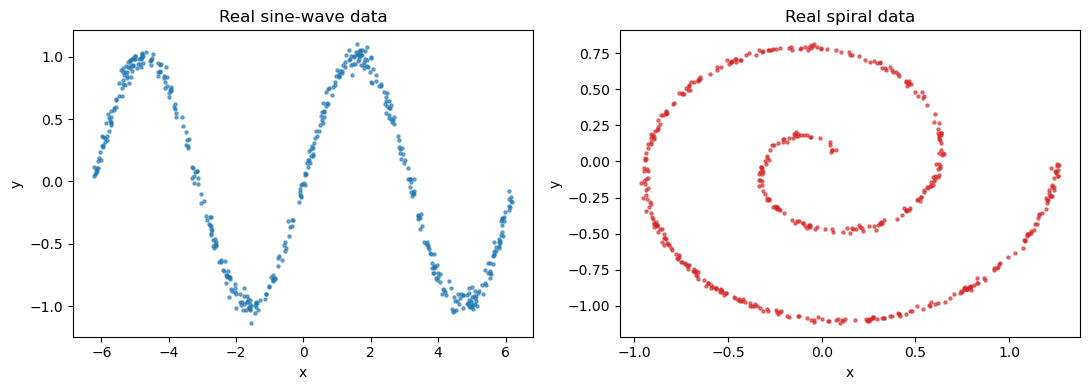

In [3]:
def sample_sine_wave(n_samples):
    """Points along y = sin(x) with a little Gaussian noise, shape (n, 2)."""
    x = np.random.uniform(-2 * np.pi, 2 * np.pi, n_samples)
    y = np.sin(x) + np.random.normal(0, 0.05, n_samples)
    return np.stack([x, y], axis=1).astype(np.float32)


def sample_spiral(n_samples, noise=0.1):
    """Archimedean spiral, scaled to about [-1.3, 1.3], shape (n, 2)."""
    theta = np.sqrt(np.random.rand(n_samples)) * 4 * np.pi  # sqrt spreads points evenly instead of bunching near the centre
    r = theta
    x = r * np.cos(theta) + np.random.normal(0, noise, n_samples)
    y = r * np.sin(theta) + np.random.normal(0, noise, n_samples)
    return (np.stack([x, y], axis=1) / 10.0).astype(np.float32)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
s = sample_sine_wave(500)
axes[0].scatter(s[:, 0], s[:, 1], s=5, alpha=0.6); axes[0].set_title("Real sine-wave data")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
sp = sample_spiral(500)
axes[1].scatter(sp[:, 0], sp[:, 1], s=5, alpha=0.6, color="tab:red"); axes[1].set_title("Real spiral data")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.tight_layout(); plt.show()

## 3. A GAN with configurable activation and depth

Rather than hard-coding two separate networks, I wrote the generator and
discriminator so that activation and depth are constructor arguments. That way
the *exact same code* builds both the baseline and the modified network in
Task 3, which is what makes the later comparison fair. The generator applies
BatchNorm after every hidden layer, and in practice that is the single change
that makes the spiral trainable at all, without it the generator kept collapsing
onto a small arc instead of tracing the whole curve. The final generator layer
is linear (no activation) because the outputs are unbounded 2D coordinates, and
the discriminator ends in a sigmoid so its output reads as a real/fake
probability.

In [4]:
def make_activation(name):
    if name == "relu":
        return nn.ReLU()
    if name == "leaky_relu":
        return nn.LeakyReLU(0.2)
    raise ValueError(f"Unknown activation: {name}")


class Generator(nn.Module):
    """Maps latent noise to a 2D point; depth and activation are configurable."""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=64, depth=2, activation="relu"):
        super().__init__()
        layers, width = [], latent_dim
        for _ in range(depth):
            layers += [nn.Linear(width, hidden_dim), nn.BatchNorm1d(hidden_dim), make_activation(activation)]
            width = hidden_dim
        layers.append(nn.Linear(width, 2))          # 2D output, no activation
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """Maps a 2D point to a real/fake probability."""
    def __init__(self, hidden_dim=64, depth=2, activation="leaky_relu"):
        super().__init__()
        layers, width = [], 2
        for _ in range(depth):
            layers += [nn.Linear(width, hidden_dim), make_activation(activation)]
            width = hidden_dim
        layers += [nn.Linear(width, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 4. Training loop

This is the standard alternating GAN update: one step for the discriminator,
then one for the generator, per batch. A few deliberate choices are worth
calling out. I use Adam with `betas=(0.5, 0.999)`, the lower `beta1` is the
usual GAN fix, since the default 0.9 makes the momentum term too sluggish and
training tends to oscillate. I also apply one-sided label smoothing (real
target 0.9 instead of 1.0), which stops the discriminator from becoming too
confident too quickly and starving the generator of gradient. Both losses are
recorded every epoch so I can plot them afterwards and check the two networks
stayed in balance.

In [5]:
def train_gan(data_sampler, generator, discriminator, n_epochs=10000,
              batch_size=128, lr=5e-4, latent_dim=LATENT_DIM, log_every=1000,
              label_smoothing=True, betas=(0.5, 0.999)):
    """Train the 2D GAN and return (g_losses, d_losses)."""
    generator.to(device); discriminator.to(device)
    criterion = nn.BCELoss()
    opt_g = optim.Adam(generator.parameters(), lr=lr, betas=betas)
    opt_d = optim.Adam(discriminator.parameters(), lr=lr, betas=betas)

    g_losses, d_losses = [], []
    real_target = 0.9 if label_smoothing else 1.0

    for epoch in range(n_epochs):
        # discriminator step
        real_data = torch.tensor(data_sampler(batch_size)).to(device)
        real_labels = torch.full((batch_size, 1), real_target, dtype=torch.float32).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        z = torch.randn(batch_size, latent_dim).to(device)
        fake_data = generator(z).detach()            # detach so G isn't updated on the D step
        d_loss = (criterion(discriminator(real_data), real_labels)
                  + criterion(discriminator(fake_data), fake_labels))
        opt_d.zero_grad(); d_loss.backward(); opt_d.step()

        # generator step
        z = torch.randn(batch_size, latent_dim).to(device)
        g_labels = torch.ones(batch_size, 1).to(device)   # G wants D to call these real
        g_loss = criterion(discriminator(generator(z)), g_labels)
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()

        g_losses.append(g_loss.item()); d_losses.append(d_loss.item())
        if (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | D {d_loss.item():.4f} | G {g_loss.item():.4f}")
    return g_losses, d_losses

## 5. Plotting helpers

Small helpers I reuse across all three tasks: one to plot the loss curves, one
to sample points from a trained generator, and one to overlay real and
generated points on the same axes. The sampling helper flips the generator into
`eval()` mode first, this matters because of BatchNorm, which behaves
differently at inference time and would otherwise distort the generated cloud.

In [6]:
def plot_losses(g_losses, d_losses, title, fname=None):
    plt.figure(figsize=(6, 4))
    plt.plot(g_losses, label="Generator loss"); plt.plot(d_losses, label="Discriminator loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(title); plt.legend()
    plt.show()


def generate(generator, n, latent_dim=LATENT_DIM):
    """Draw n fake points; eval mode matters here because of BatchNorm."""
    generator.eval()
    with torch.no_grad():
        out = generator(torch.randn(n, latent_dim).to(device)).cpu().numpy()
    generator.train()
    return out


def plot_real_vs_fake(real_data, generator, title, fname=None):
    fake = generate(generator, 500)
    plt.figure(figsize=(6, 5))
    plt.scatter(real_data[:, 0], real_data[:, 1], s=8, alpha=0.5, label="Real")
    plt.scatter(fake[:, 0], fake[:, 1], s=8, alpha=0.5, label="Generated")
    plt.legend(); plt.title(title)
    plt.show()

## Task 1: Reproduce the sine-wave GAN

Epoch 1000/5000 | D 1.3462 | G 0.8394
Epoch 2000/5000 | D 1.3586 | G 0.8211
Epoch 3000/5000 | D 1.3645 | G 0.8181
Epoch 4000/5000 | D 1.3670 | G 0.7924
Epoch 5000/5000 | D 1.3555 | G 0.8251


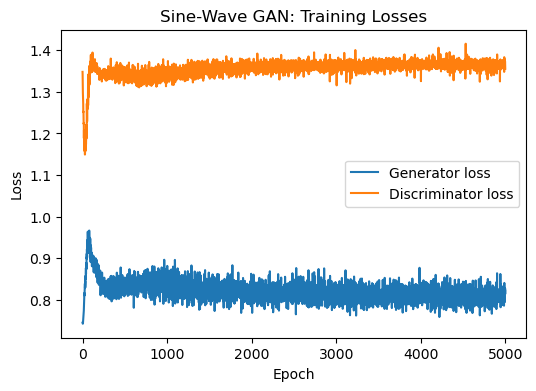

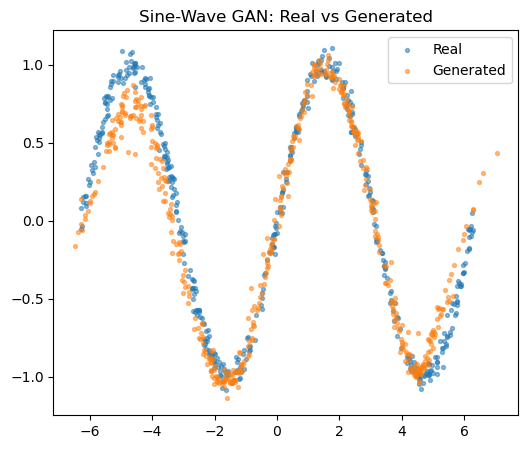

In [7]:
torch.manual_seed(42); np.random.seed(42)
gen_sine = Generator(depth=2, activation="relu")
disc_sine = Discriminator(depth=2, activation="leaky_relu")
gl, dl = train_gan(sample_sine_wave, gen_sine, disc_sine, n_epochs=5000)

plot_losses(gl, dl, "Sine-Wave GAN: Training Losses", None)
plot_real_vs_fake(sample_sine_wave(500), gen_sine, "Sine-Wave GAN: Real vs Generated", None)

## Task 2: A new 2D distribution (spiral)

Epoch 1000/10000 | D 1.3629 | G 0.8079
Epoch 2000/10000 | D 1.3623 | G 0.8265
Epoch 3000/10000 | D 1.3462 | G 0.8032
Epoch 4000/10000 | D 1.3180 | G 0.8120
Epoch 5000/10000 | D 1.3161 | G 0.8598
Epoch 6000/10000 | D 1.3202 | G 0.8349
Epoch 7000/10000 | D 1.2858 | G 0.8628
Epoch 8000/10000 | D 1.2552 | G 0.8645
Epoch 9000/10000 | D 1.3047 | G 0.8190
Epoch 10000/10000 | D 1.3276 | G 0.8151


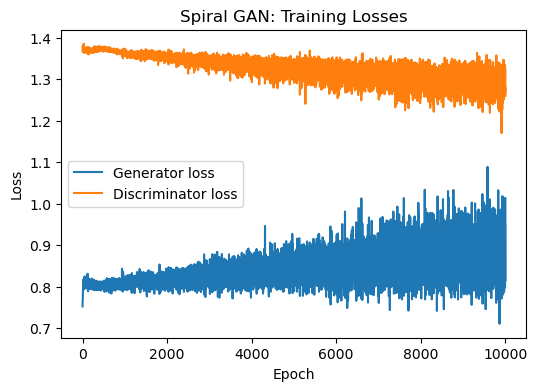

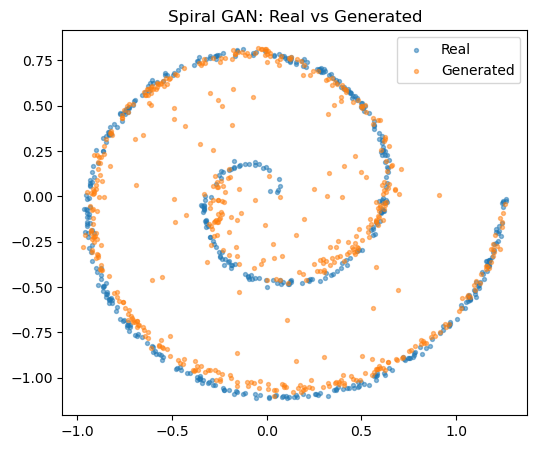

In [8]:
torch.manual_seed(42); np.random.seed(42)
gen_spiral = Generator(depth=2, activation="relu")
disc_spiral = Discriminator(depth=2, activation="leaky_relu")
gl, dl = train_gan(sample_spiral, gen_spiral, disc_spiral, n_epochs=10000)

plot_losses(gl, dl, "Spiral GAN: Training Losses", None)
plot_real_vs_fake(sample_spiral(500), gen_spiral, "Spiral GAN: Real vs Generated", None)

## Task 3: Change the architecture and compare

For the architecture experiment I change exactly two things and hold everything
else constant (latent dimension, hidden width, learning rate, epoch count,
BatchNorm, label smoothing). Isolating the change like this is the whole point,
if I varied several things at once I couldn't attribute any improvement to a
specific cause. The modified generator is both deeper (more capacity to bend a
thin curve) and uses a non-saturating activation (LeakyReLU keeps a small
gradient for negative inputs, so units are less likely to go permanently dead).

| | Original | Modified |
|---|---|---|
| Activation | ReLU | **LeakyReLU(0.2)** |
| Hidden depth | 2 | **4** |

Epoch 1000/10000 | D 1.3629 | G 0.8079
Epoch 2000/10000 | D 1.3623 | G 0.8265
Epoch 3000/10000 | D 1.3462 | G 0.8032
Epoch 4000/10000 | D 1.3180 | G 0.8120
Epoch 5000/10000 | D 1.3161 | G 0.8598
Epoch 6000/10000 | D 1.3202 | G 0.8349
Epoch 7000/10000 | D 1.2858 | G 0.8628
Epoch 8000/10000 | D 1.2552 | G 0.8645
Epoch 9000/10000 | D 1.3047 | G 0.8190
Epoch 10000/10000 | D 1.3276 | G 0.8151
Epoch 1000/10000 | D 1.2356 | G 1.0780
Epoch 2000/10000 | D 1.2095 | G 1.3149
Epoch 3000/10000 | D 1.1865 | G 1.0817
Epoch 4000/10000 | D 1.1064 | G 1.7878
Epoch 5000/10000 | D 1.3255 | G 1.2791
Epoch 6000/10000 | D 1.1713 | G 1.2262
Epoch 7000/10000 | D 1.2673 | G 0.9410
Epoch 8000/10000 | D 1.2516 | G 0.8865
Epoch 9000/10000 | D 1.3184 | G 1.0468
Epoch 10000/10000 | D 1.2497 | G 1.1947


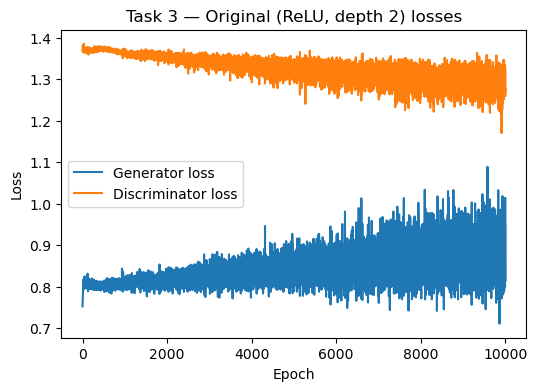

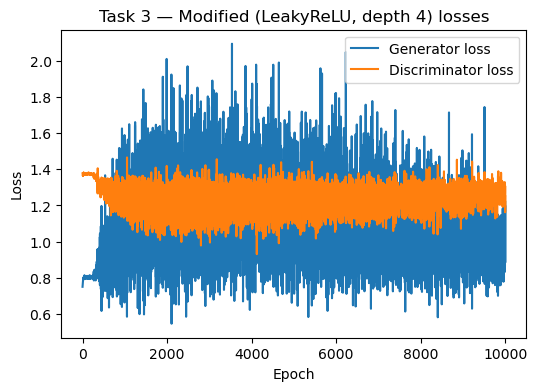

In [9]:
# original: ReLU, depth 2
torch.manual_seed(42); np.random.seed(42)
gen_orig = Generator(depth=2, activation="relu")
disc_orig = Discriminator(depth=2, activation="leaky_relu")
gl_o, dl_o = train_gan(sample_spiral, gen_orig, disc_orig, n_epochs=10000)

# modified: LeakyReLU, depth 4 (everything else identical)
torch.manual_seed(42); np.random.seed(42)
gen_mod = Generator(depth=4, activation="leaky_relu")
disc_mod = Discriminator(depth=4, activation="leaky_relu")
gl_m, dl_m = train_gan(sample_spiral, gen_mod, disc_mod, n_epochs=10000)

plot_losses(gl_o, dl_o, "Task 3 — Original (ReLU, depth 2) losses", None)
plot_losses(gl_m, dl_m, "Task 3 — Modified (LeakyReLU, depth 4) losses", None)

### Real vs original vs modified

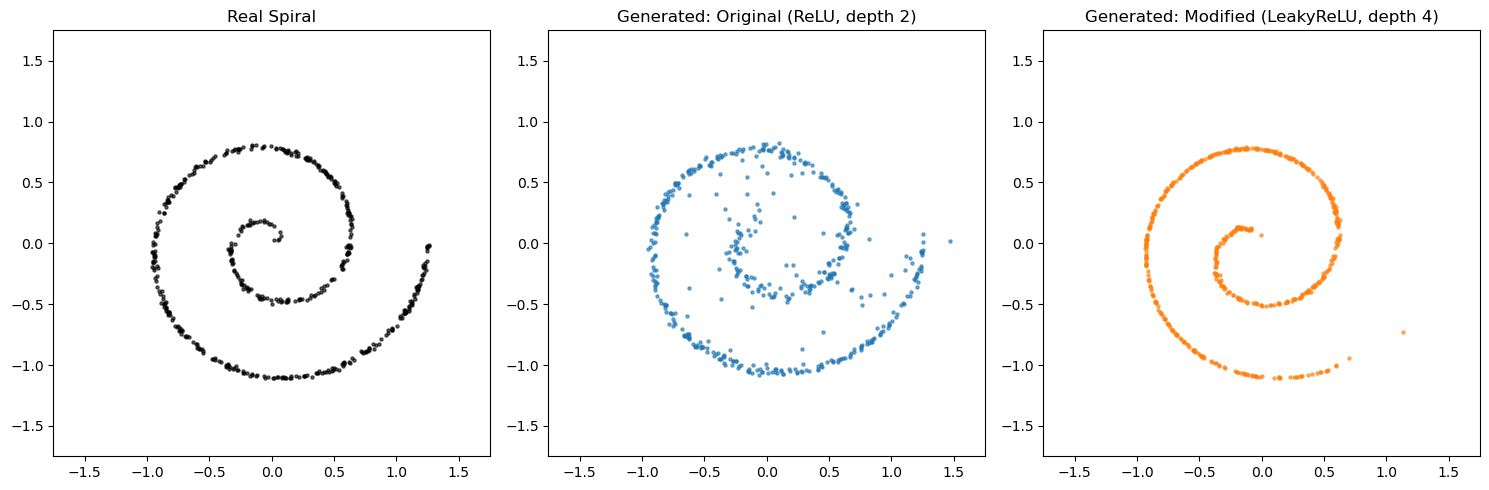

In [10]:
real_plot = sample_spiral(500)
fake_orig = generate(gen_orig, 500)
fake_mod = generate(gen_mod, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (data, title, color) in zip(axes, [
    (real_plot, "Real Spiral", "black"),
    (fake_orig, "Generated: Original (ReLU, depth 2)", "tab:blue"),
    (fake_mod, "Generated: Modified (LeakyReLU, depth 4)", "tab:orange"),
]):
    ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.6, color=color)
    ax.set_title(title); ax.set_xlim(-1.75, 1.75); ax.set_ylim(-1.75, 1.75)
plt.tight_layout(); plt.show()

## Part 1 summary

* **Task 1 (sine wave).** The losses settle into a healthy equilibrium, the
  discriminator sits just above 1.35 and the generator around 0.82, which is the
  region you'd expect when neither network is running away with it. Visually the
  generated points follow `y = sin(x)` across the full range. Coverage thins a
  little right at the crests of the peaks, but the shape is clearly correct, so
  the baseline reproduces the tutorial result.
* **Task 2 (spiral).** This is a much harder, multi-turn target, yet the
  generator still recovers both arms and the curl in the centre, and the
  generated cloud lands on top of the real spiral. It's worth being honest that
  this only works because of the stabilisers, BatchNorm, the tuned Adam betas,
  label smoothing, and enough epochs. Without them the same model collapses to a
  blob near the origin.
* **Task 3 (architecture change).** Changing only the activation (ReLU ->
  LeakyReLU) and the depth (2 -> 4 hidden layers) makes a visible difference on
  the spiral. The original scatters a fair number of stray points off the curve
  and partly fills the empty centre, while the deeper LeakyReLU model traces a
  tighter, cleaner spiral along both arms with far less noise. The trade-off
  shows up in the loss curves: the modified generator's loss runs higher and
  noisier (it fluctuates up towards 1.5-1.8 at times rather than sitting flat),
  which is consistent with a harder-working generator pushing against a
  discriminator it can't easily satisfy. The takeaway is that the extra depth
  plus the non-saturating activation give the generator enough capacity to fit a
  thin 1D curve embedded in 2D more precisely.

---

# Part 2: Real-World GAN Applications


## TensorFlow/Keras setup (shared across the TensorFlow parts)

The image GANs in Part 2 (2.1 and 2.3) are written in TensorFlow/Keras, which
the brief explicitly allows alongside PyTorch. I split it this way on purpose:
Keras is convenient for the convolutional DCGANs and for reusing InceptionV3 to
compute FID, while the tabular GAN in 2.2 stays in PyTorch where the plain-MLP
setup is quick to write. Everything the two image parts share lives in this
block: the DCGAN generator upsamples with `Conv2DTranspose` layers (each
followed by BatchNorm + ReLU), the discriminator downsamples with strided
`Conv2D` + LeakyReLU, each training step runs two `tf.GradientTape`s with
one-sided label smoothing, and FID is read off InceptionV3's 2048-dimensional
pooled features. Defining these once keeps 2.1 and 2.3 consistent and avoids
copy-pasting the same architecture twice.

In [11]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # quieten TF's C++ logging

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential, optimizers, losses
from tensorflow.keras.applications import InceptionV3
import matplotlib.pyplot as plt

# grow GPU memory on demand instead of grabbing it all, so the PyTorch parts still have room
for _gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except Exception:
        pass

TF_SEED = 1337
tf.random.set_seed(TF_SEED)
np.random.seed(TF_SEED)

TF_RESULTS_DIR = "results_set1"
os.makedirs(TF_RESULTS_DIR, exist_ok=True)
print("TensorFlow", tf.__version__, "| Keras", tf.keras.__version__, "| results ->", TF_RESULTS_DIR)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.21.0 | Keras 3.12.4 | results -> results_set1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
# Frechet Inception Distance, shared by all the TF image parts.
_inception_fid_model = None


def _get_inception_fid():
    """Build the InceptionV3 feature extractor once, on first use."""
    global _inception_fid_model
    if _inception_fid_model is None:
        _inception_fid_model = InceptionV3(include_top=False, pooling="avg",
                                           weights="imagenet", input_shape=(299, 299, 3))
    return _inception_fid_model


def inception_features(images_unit_range, batch=50):
    """(N, H, W, 1) images in [0, 1] -> (N, 2048) pooled InceptionV3 features."""
    model = _get_inception_fid()
    collected = []
    for start in range(0, images_unit_range.shape[0], batch):
        chunk = tf.convert_to_tensor(images_unit_range[start:start + batch], dtype=tf.float32)
        chunk = tf.image.resize(chunk, (299, 299))
        if chunk.shape[-1] == 1:
            chunk = tf.repeat(chunk, 3, axis=-1)
        chunk = tf.keras.applications.inception_v3.preprocess_input(chunk * 255.0)
        collected.append(model.predict(chunk, verbose=0))
    return np.concatenate(collected, axis=0)


def frechet_inception_distance(real_unit_range, fake_unit_range, eps=1e-6):
    """FID between two image sets given in the [0, 1] range (lower is better)."""
    import scipy.linalg
    real_features = inception_features(real_unit_range)
    fake_features = inception_features(fake_unit_range)
    mu_real, mu_fake = real_features.mean(0), fake_features.mean(0)
    cov_real = np.cov(real_features, rowvar=False)
    cov_fake = np.cov(fake_features, rowvar=False)
    mean_diff = mu_real - mu_fake
    root = scipy.linalg.sqrtm(cov_real @ cov_fake)
    if isinstance(root, tuple):
        root = root[0]
    if not np.isfinite(root).all():
        offset = np.eye(cov_real.shape[0]) * eps
        root = scipy.linalg.sqrtm((cov_real + offset) @ (cov_fake + offset))
        if isinstance(root, tuple):
            root = root[0]
    if np.iscomplexobj(root):
        root = root.real
    return float(mean_diff @ mean_diff + np.trace(cov_real + cov_fake - 2.0 * root))

In [13]:
# Preprocessing and plotting helpers for the TF image parts.
def preprocess_tf_images(images_uint8, size=32):
    """(N, H, W) uint8 -> (N, size, size, 1) float32 in [-1, 1] (channel-last)."""
    x = images_uint8.astype("float32")[..., None] / 127.5 - 1.0
    if x.shape[1] != size:
        x = tf.image.resize(x, (size, size)).numpy().astype("float32")
    return x


def to_unit_range(images_pm1):
    """[-1, 1] -> [0, 1] for FID."""
    return (np.clip(images_pm1, -1.0, 1.0) + 1.0) / 2.0


def tf_show_grid(images_pm1, title, path=None, ncols=8):
    """Render a grid of channel-last images given in [-1, 1]."""
    imgs = to_unit_range(np.asarray(images_pm1))
    count = imgs.shape[0]
    nrows = int(np.ceil(count / ncols))
    plt.figure(figsize=(ncols, nrows))
    for i in range(count):
        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(imgs[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()


def tf_show_real_vs_fake(real_pm1, fake_pm1, title, path=None, shown=32):
    """Side-by-side real vs generated grids (channel-last, [-1, 1])."""
    figure, axes = plt.subplots(1, 2, figsize=(12, 6))
    for axis, batch, name in ((axes[0], real_pm1, "Real"), (axes[1], fake_pm1, "Generated")):
        imgs = to_unit_range(np.asarray(batch)[:shown])
        side = int(np.ceil(np.sqrt(imgs.shape[0])))
        canvas = np.ones((side * 32, side * 32))
        for i in range(imgs.shape[0]):
            r, c = divmod(i, side)
            canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = imgs[i, :, :, 0]
        axis.imshow(canvas, cmap="gray"); axis.set_title(name); axis.axis("off")
    figure.suptitle(title)
    plt.show()


def tf_show_epoch_progression(snapshots, title, path=None):
    """snapshots: list of (epoch, image_batch[-1,1]) -> side-by-side grids across epochs."""
    if not snapshots:
        return
    cols = len(snapshots)
    figure, axes = plt.subplots(1, cols, figsize=(3.0 * cols, 3.2))
    if cols == 1:
        axes = [axes]
    for axis, (epoch, batch) in zip(axes, snapshots):
        imgs = to_unit_range(np.asarray(batch)[:16])
        canvas = np.ones((4 * 32, 4 * 32))
        for i in range(min(16, imgs.shape[0])):
            r, c = divmod(i, 4)
            canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = imgs[i, :, :, 0]
        axis.imshow(canvas, cmap="gray"); axis.set_title(f"epoch {epoch}"); axis.axis("off")
    figure.suptitle(title)
    plt.show()


def tf_plot_losses(discriminator_history, generator_history, title, path=None):
    """Plot discriminator vs generator loss traces."""
    plt.figure(figsize=(8, 4))
    plt.plot(discriminator_history, label="Discriminator", color="#1f77b4", alpha=0.85)
    plt.plot(generator_history, label="Generator", color="#d62728", alpha=0.85)
    plt.title(title); plt.xlabel("training step"); plt.ylabel("BCE loss")
    plt.legend(); plt.grid(alpha=0.2)
    plt.show()

In [14]:
# DCGAN and conditional-DCGAN builders and trainers (Keras).
def _kernel_init(name):
    """Turn an init name into a Keras initializer."""
    if name == "dcgan":
        return tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02)
    if name == "he":
        return "he_normal"
    return "glorot_uniform"


def build_dcgan_generator(latent_dim, feature_maps=64, weight_init="dcgan"):
    """Latent vector -> (32, 32, 1) image in [-1, 1] via fractionally-strided convs."""
    init = _kernel_init(weight_init)
    return Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(4 * 4 * feature_maps * 4, use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(), layers.ReLU(),
        layers.Reshape((4, 4, feature_maps * 4)),
        layers.Conv2DTranspose(feature_maps * 2, 4, 2, "same", use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(), layers.ReLU(),                                       # 8x8
        layers.Conv2DTranspose(feature_maps, 4, 2, "same", use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(), layers.ReLU(),                                       # 16x16
        layers.Conv2DTranspose(1, 4, 2, "same", use_bias=False, activation="tanh", kernel_initializer=init),
    ], name="dcgan_generator")                                                            # 32x32


def build_dcgan_discriminator(feature_maps=64, weight_init="dcgan", dropout=0.0):
    """(32, 32, 1) image -> single real/fake logit (no sigmoid)."""
    init = _kernel_init(weight_init)
    model = Sequential(name="dcgan_discriminator")
    model.add(layers.Input(shape=(32, 32, 1)))
    model.add(layers.Conv2D(feature_maps, 4, 2, "same", kernel_initializer=init))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Conv2D(feature_maps * 2, 4, 2, "same", kernel_initializer=init))
    model.add(layers.BatchNormalization()); model.add(layers.LeakyReLU(0.2))
    model.add(layers.Conv2D(feature_maps * 4, 4, 2, "same", kernel_initializer=init))
    model.add(layers.BatchNormalization()); model.add(layers.LeakyReLU(0.2))
    if dropout > 0:
        model.add(layers.Dropout(dropout))
    model.add(layers.Flatten())
    model.add(layers.Dense(1, kernel_initializer=init))
    return model


def train_dcgan(generator, discriminator, dataset, epochs, latent_dim,
                learning_rate=2e-4, beta_1=0.5, label_smoothing=0.9, snapshots=5):
    """Train an unconditional DCGAN; return (d_history, g_history, epoch_snapshots)."""
    g_opt = optimizers.Adam(learning_rate, beta_1=beta_1)
    d_opt = optimizers.Adam(learning_rate, beta_1=beta_1)
    bce = losses.BinaryCrossentropy(from_logits=True)

    @tf.function
    def step(real_images):
        batch = tf.shape(real_images)[0]
        noise = tf.random.normal((batch, latent_dim))
        with tf.GradientTape() as d_tape, tf.GradientTape() as g_tape:
            fake_images = generator(noise, training=True)
            real_logits = discriminator(real_images, training=True)
            fake_logits = discriminator(fake_images, training=True)
            d_loss = (bce(tf.ones_like(real_logits) * label_smoothing, real_logits)
                      + bce(tf.zeros_like(fake_logits), fake_logits))
            g_loss = bce(tf.ones_like(fake_logits), fake_logits)
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))
        g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                  generator.trainable_variables))
        return d_loss, g_loss

    d_history, g_history, progression = [], [], []
    snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, epochs, snapshots)))
    fixed_noise = tf.random.normal((16, latent_dim))
    for epoch in range(1, epochs + 1):
        d_last, g_last = 0.0, 0.0
        for real_images in dataset:
            d_last, g_last = step(real_images)
            d_history.append(float(d_last)); g_history.append(float(g_last))
        print(f"epoch {epoch:>3}/{epochs} | D={float(d_last):.4f} | G={float(g_last):.4f}")
        if epoch in snapshot_epochs:
            progression.append((epoch, generator(fixed_noise, training=False).numpy()))
    return d_history, g_history, progression


@tf.autograph.experimental.do_not_convert
def generate_tf_images(generator, count, latent_dim):
    """Sample a batch of generated images in [-1, 1] from a trained generator."""
    noise = tf.random.normal((count, latent_dim))
    return generator(noise, training=False).numpy()

In [15]:
# Conditional DCGAN for the cGAN extension: the label is embedded into the generator
# input and added as an extra channel for the discriminator (standard cGAN-DCGAN setup).
def build_conditional_generator(num_classes, latent_dim, feature_maps=64,
                                embedding_dim=50, weight_init="dcgan"):
    init = _kernel_init(weight_init)
    noise_input = layers.Input(shape=(latent_dim,))
    label_input = layers.Input(shape=(), dtype="int32")
    label_vector = layers.Embedding(num_classes, embedding_dim)(label_input)
    x = layers.Concatenate()([noise_input, label_vector])
    x = layers.Dense(4 * 4 * feature_maps * 4, use_bias=False, kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Reshape((4, 4, feature_maps * 4))(x)
    x = layers.Conv2DTranspose(feature_maps * 2, 4, 2, "same", use_bias=False, kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(feature_maps, 4, 2, "same", use_bias=False, kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    output = layers.Conv2DTranspose(1, 4, 2, "same", use_bias=False, activation="tanh", kernel_initializer=init)(x)
    return Model([noise_input, label_input], output, name="conditional_generator")


def build_conditional_discriminator(num_classes, feature_maps=64, image_size=32, weight_init="dcgan"):
    init = _kernel_init(weight_init)
    image_input = layers.Input(shape=(image_size, image_size, 1))
    label_input = layers.Input(shape=(), dtype="int32")
    label_map = layers.Embedding(num_classes, image_size * image_size)(label_input)
    label_map = layers.Reshape((image_size, image_size, 1))(label_map)
    x = layers.Concatenate()([image_input, label_map])
    x = layers.Conv2D(feature_maps, 4, 2, "same", kernel_initializer=init)(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(feature_maps * 2, 4, 2, "same", kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(feature_maps * 4, 4, 2, "same", kernel_initializer=init)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    output = layers.Dense(1, kernel_initializer=init)(x)
    return Model([image_input, label_input], output, name="conditional_discriminator")


def train_conditional_dcgan(generator, discriminator, dataset, epochs, num_classes, latent_dim,
                            learning_rate=1e-4, beta_1=0.5, label_smoothing=0.9):
    """Train the conditional DCGAN; dataset yields (images, labels)."""
    g_opt = optimizers.Adam(learning_rate, beta_1=beta_1)
    d_opt = optimizers.Adam(learning_rate, beta_1=beta_1)
    bce = losses.BinaryCrossentropy(from_logits=True)

    @tf.function
    def step(real_images, real_labels):
        batch = tf.shape(real_images)[0]
        noise = tf.random.normal((batch, latent_dim))
        sampled_labels = tf.random.uniform((batch,), 0, num_classes, dtype=tf.int32)
        with tf.GradientTape() as d_tape, tf.GradientTape() as g_tape:
            fake_images = generator([noise, sampled_labels], training=True)
            real_logits = discriminator([real_images, real_labels], training=True)
            fake_logits = discriminator([fake_images, sampled_labels], training=True)
            d_loss = (bce(tf.ones_like(real_logits) * label_smoothing, real_logits)
                      + bce(tf.zeros_like(fake_logits), fake_logits))
            g_loss = bce(tf.ones_like(fake_logits), fake_logits)
        d_opt.apply_gradients(zip(d_tape.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))
        g_opt.apply_gradients(zip(g_tape.gradient(g_loss, generator.trainable_variables),
                                  generator.trainable_variables))
        return d_loss, g_loss

    d_history, g_history = [], []
    for epoch in range(1, epochs + 1):
        d_last, g_last = 0.0, 0.0
        for real_images, real_labels in dataset:
            d_last, g_last = step(real_images, real_labels)
            d_history.append(float(d_last)); g_history.append(float(g_last))
        print(f"[cGAN] epoch {epoch:>3}/{epochs} | D={float(d_last):.4f} | G={float(g_last):.4f}")
    return d_history, g_history

# Part 2.1: OCTMNIST retinal images with a DCGAN (TensorFlow/Keras)

OCTMNIST (part of the MedMNIST collection) is a set of 28x28 grayscale optical
coherence tomography retinal scans spread across four diagnostic categories. A
DCGAN is a sensible choice here because the useful structure in these scans, the
curved retinal band and the layering underneath it, is spatial and local, which
is exactly what convolutional filters capture; a fully-connected GAN would have
to relearn that spatial structure from scratch. The plan for this section is to
explore the data first (class balance and a look at real scans), train an
unconditional DCGAN to generate scans, evaluate it visually and with FID, and
then finish with the conditional-GAN extension that can produce a chosen
diagnostic class on demand.

In [16]:
# OCTMNIST DCGAN config
OCT_LATENT = 100
OCT_NGF = 64
OCT_NDF = 64
OCT_LR = 0.0002
OCT_BETA1 = 0.5
OCT_EPOCHS = 60
OCT_BATCH = 128
OCT_MAX_IMAGES = 30000
OCT_FID_SAMPLES = 2000
OCT_INIT = "dcgan"
OCT_CGAN_EMB = 50
OCT_CGAN_LR = 0.0001
OCT_CGAN_EPOCHS = 50
print("OCTMNIST TF config:", dict(latent=OCT_LATENT, ngf=OCT_NGF, ndf=OCT_NDF, lr=OCT_LR,
                                  epochs=OCT_EPOCHS, batch=OCT_BATCH, init=OCT_INIT))

OCTMNIST TF config: {'latent': 100, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'epochs': 60, 'batch': 128, 'init': 'dcgan'}


## 2.1.1 Load and explore OCTMNIST

OCTMNIST classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}
OCTMNIST train images: (97477, 28, 28)


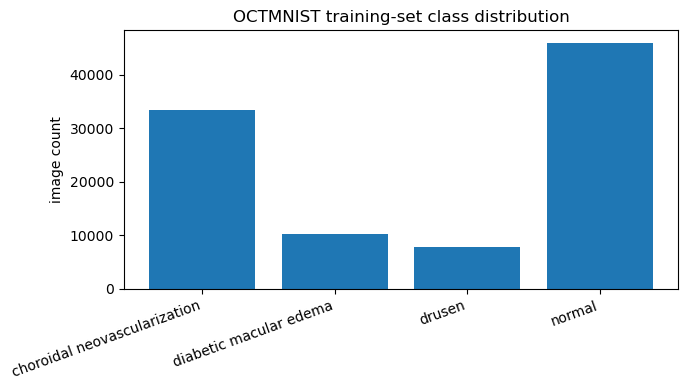

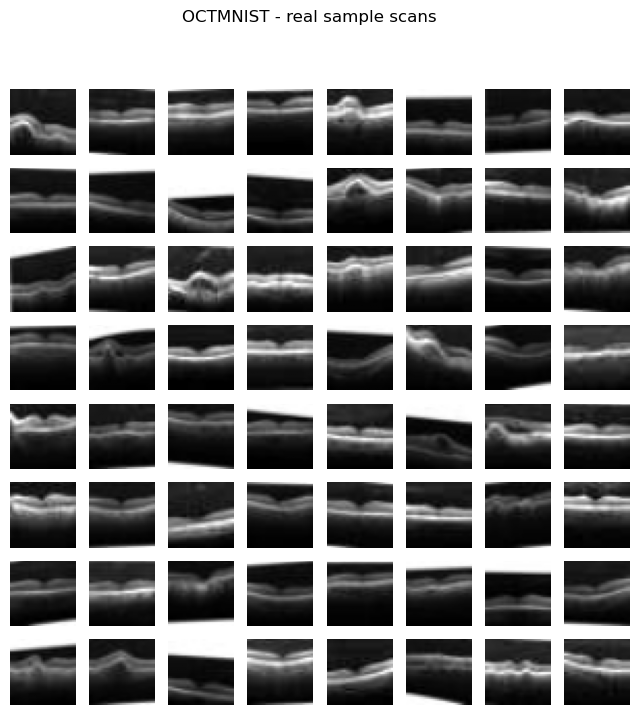

In [17]:
import sys
import subprocess

# --no-deps so installing medmnist doesn't disturb the existing numpy/torch (we only use its arrays)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "medmnist"], check=False)

from medmnist import OCTMNIST, INFO

octmnist_class_names = INFO["octmnist"]["label"]
octmnist_train = OCTMNIST(split="train", download=True)
octmnist_images = octmnist_train.imgs                 # (N, 28, 28) uint8
octmnist_labels = octmnist_train.labels.flatten()      # (N,)
octmnist_num_classes = len(octmnist_class_names)
print("OCTMNIST classes:", octmnist_class_names)
print("OCTMNIST train images:", octmnist_images.shape)

# class distribution
unique_classes, class_counts = np.unique(octmnist_labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([octmnist_class_names[str(int(c))] for c in unique_classes], class_counts, color="#1f77b4")
plt.title("OCTMNIST training-set class distribution")
plt.ylabel("image count"); plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.show()

# a few real scans
tf_show_grid(preprocess_tf_images(octmnist_images[:64]), "OCTMNIST - real sample scans",
             None)

## 2.1.2 Build and train the DCGAN

Model: "dcgan_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 1)      │         1,024 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,083,136 (4.13 MB)

 Trainable params: 1,074,560 (4.10 MB)

 Non-trainable params: 8,576 (33.50 KB)

E0000 00:00:1785746682.360474  623463 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape indcgan_discriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


epoch   1/60 | D=0.3719 | G=5.4219
epoch   2/60 | D=1.5382 | G=0.5244
epoch   3/60 | D=0.6935 | G=3.0499
epoch   4/60 | D=0.7037 | G=1.6910
epoch   5/60 | D=0.5904 | G=2.0041
epoch   6/60 | D=1.0196 | G=2.4254
epoch   7/60 | D=0.6800 | G=1.6527
epoch   8/60 | D=0.7492 | G=2.6147
epoch   9/60 | D=0.6909 | G=3.1784
epoch  10/60 | D=0.4009 | G=4.4964
epoch  11/60 | D=0.4642 | G=3.0279
epoch  12/60 | D=0.5725 | G=4.9739
epoch  13/60 | D=0.4940 | G=5.0636
epoch  14/60 | D=0.4724 | G=2.8591
epoch  15/60 | D=0.4049 | G=4.3086
epoch  16/60 | D=1.5941 | G=2.2630
epoch  17/60 | D=0.5207 | G=2.5626
epoch  18/60 | D=0.5821 | G=4.8921
epoch  19/60 | D=0.5556 | G=3.4819
epoch  20/60 | D=0.6904 | G=1.6998
epoch  21/60 | D=0.4308 | G=3.1309
epoch  22/60 | D=0.4559 | G=4.1603
epoch  23/60 | D=0.4062 | G=3.6680
epoch  24/60 | D=0.5145 | G=2.9899
epoch  25/60 | D=0.4778 | G=5.1414
epoch  26/60 | D=0.8717 | G=1.3924
epoch  27/60 | D=0.4192 | G=4.5509
epoch  28/60 | D=0.4045 | G=3.6658
epoch  29/60 | D=0.4

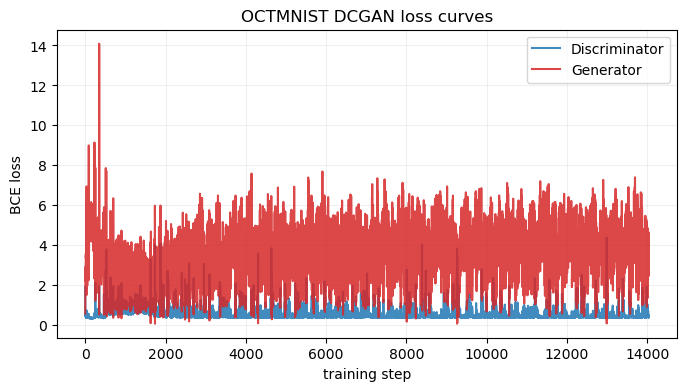

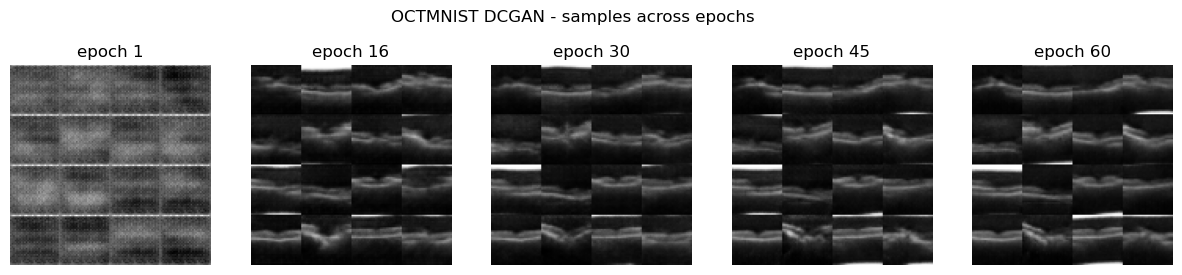

In [18]:
def train_image_dcgan(images, max_images, latent, ngf, ndf, init, batch, epochs, lr, beta1,
                      loss_title, loss_path, prog_title, prog_path,
                      disc_dropout=0.0, show_summary=False):
    """Shared TF DCGAN image pipeline: subsample+scale an image array, build the DCGAN,
    train it, and plot losses + the epoch progression. Returns (generator, d_hist, g_hist, snaps).
    Per-part differences (discriminator dropout, whether to print a summary, configs, titles,
    paths) are passed in, so OCT and QuickDraw reuse this without changing their behavior."""
    np.random.seed(TF_SEED); tf.random.set_seed(TF_SEED)
    subset = np.random.permutation(len(images))[:max_images]
    x = preprocess_tf_images(images[subset])
    dataset = (tf.data.Dataset.from_tensor_slices(x)
               .shuffle(min(len(x), 10000))
               .batch(batch, drop_remainder=True)
               .prefetch(tf.data.AUTOTUNE))
    generator = build_dcgan_generator(latent, ngf, weight_init=init)
    discriminator = build_dcgan_discriminator(ndf, weight_init=init, dropout=disc_dropout)
    if show_summary:
        generator.summary()
    d_hist, g_hist, snaps = train_dcgan(generator, discriminator, dataset,
                                        epochs, latent, learning_rate=lr, beta_1=beta1)
    tf_plot_losses(d_hist, g_hist, loss_title, loss_path)
    tf_show_epoch_progression(snaps, prog_title, prog_path)
    return generator, d_hist, g_hist, snaps

octmnist_generator, octmnist_d_hist, octmnist_g_hist, octmnist_snaps = train_image_dcgan(
    octmnist_images, OCT_MAX_IMAGES, OCT_LATENT, OCT_NGF, OCT_NDF, OCT_INIT,
    OCT_BATCH, OCT_EPOCHS, OCT_LR, OCT_BETA1,
    "OCTMNIST DCGAN loss curves", None,
    "OCTMNIST DCGAN - samples across epochs", None,
    disc_dropout=0.3, show_summary=True)


## 2.1.3 Generate, compare against real, and compute FID

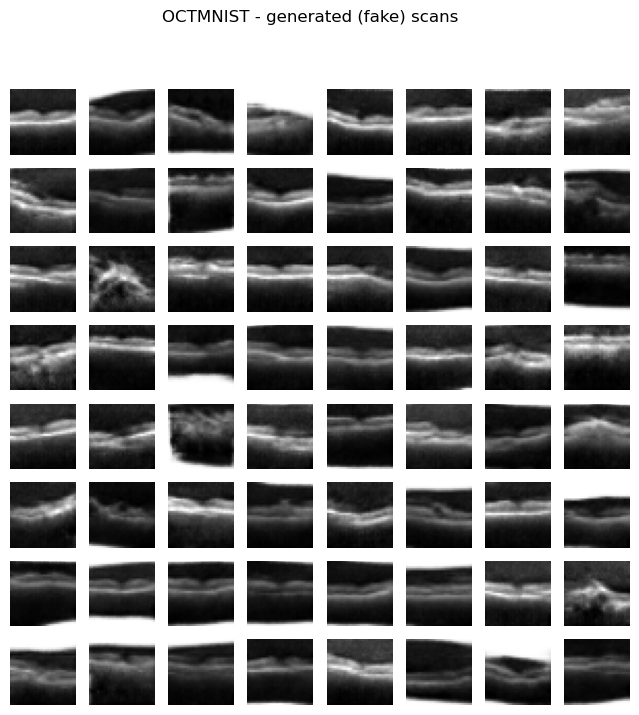

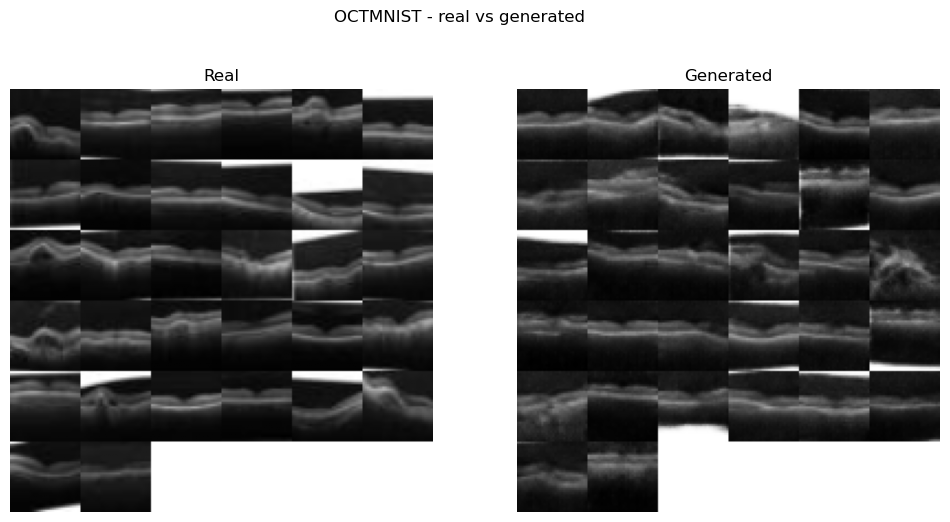

OCTMNIST DCGAN FID (lower is better): 66.83


In [19]:
def evaluate_image_dcgan(generator, images, latent, fid_samples, label,
                         grid_title, grid_path, rvf_title, rvf_path):
    """Generate fakes, show a sample grid + a real-vs-generated panel, and compute FID
    against a fresh real sample. Returns (fake_images, fid). Shared by OCT and QuickDraw."""
    fake = generate_tf_images(generator, fid_samples, latent)
    tf_show_grid(fake[:64], grid_title, grid_path)
    tf_show_real_vs_fake(preprocess_tf_images(images[:32]), fake[:32], rvf_title, rvf_path)
    fid_idx = np.random.permutation(len(images))[:fid_samples]
    real_unit = to_unit_range(preprocess_tf_images(images[fid_idx]))
    fid = frechet_inception_distance(real_unit, to_unit_range(fake))
    print(f"{label} FID (lower is better): {fid:.2f}")
    return fake, fid

octmnist_fake, octmnist_fid = evaluate_image_dcgan(
    octmnist_generator, octmnist_images, OCT_LATENT, OCT_FID_SAMPLES, "OCTMNIST DCGAN",
    "OCTMNIST - generated (fake) scans", None,
    "OCTMNIST - real vs generated", None)


## 2.1.4 Reflection

- **Quality.** The generated scans clearly capture the dominant OCT structure, a bright curved retinal band sitting over a darker background, and the batch shows genuine variety rather than one image repeated, so there's no obvious mode collapse. The epoch snapshots (taken at epochs 1, 16, 30, 45 and 60) tell the expected story: near-random texture at epoch 1, a recognisable layered band emerging by the middle snapshots, and only small refinements after that. The honest weakness is fidelity, the fakes are softer and blurrier than the real scans, and the fine sub-layers and speckle aren't fully recovered.
- **Losses.** The loss curves back this up. The discriminator loss stays low (roughly 0.4-0.6) while the generator loss bounces around in the 2-5 range without ever collapsing or exploding. That pattern, a discriminator that keeps a modest edge but never wins outright, is what you want to see; it means the generator kept receiving usable gradient for the full 60 epochs.
- **Metric.** FID came out at **66.83** (lower is better), which is on the high side and matches the visible blur. That isn't surprising: I trained for 60 epochs on a 30k subset, upscaled the scans from 28 to 32 pixels, and FID is computed with an InceptionV3 network trained on natural ImageNet photos rather than single-channel medical images, so the feature space isn't a perfect fit for this domain. FID also moves around a little between runs even with a fixed seed, because not every GPU op is fully deterministic, so I read the exact number as indicative rather than precise.
- **On using GANs to generate "ducks" (hallucination).** The phrase comes from the duck test, if it looks like a duck and quacks like a duck, we call it a duck, but fooling exactly that kind of surface judgement is a GAN's entire objective. The discriminator is only ever trained to answer "real or fake", never to check that a generated structure corresponds to real physiology, so nothing in the objective stops the generator from inventing a bright band, a lesion-like patch, or a layer boundary that never occurred in any real patient, as long as it looks statistically plausible. That is the core danger of treating GAN output as data: it is optimised for looking real, not for being true. In a retinal-scan context a hallucinated bright region could mimic a sign of disease that isn't there, or smooth over a real anomaly that should have been visible, so a synthetic scan should never be used as a real diagnostic image. The defensible uses are augmentation (padding out a training set) and teaching (illustrating roughly what pathology looks like), and any model trained partly on synthetic scans should still be validated against a real-only holdout set to make sure it hasn't just learned to spot GAN artefacts.

## 2.1 extension: Conditional GAN (generate a chosen class on demand)

The unconditional DCGAN above can only produce "some retinal scan", it has no
handle to ask for a particular diagnosis. The conditional GAN fixes that by
feeding the class label into both networks: on the generator side the label is
embedded and concatenated with the latent vector, and on the discriminator side
it is embedded, reshaped to an image-sized map, and added as an extra channel.
That forces the discriminator to judge whether an image is realistic *for the
requested class*, which in turn pushes the generator to make the label
meaningful. Two practical tweaks help it train: I oversample every class up to
the same count so the model can't just ignore the rarer diagnoses in an
imbalanced dataset, and I give the discriminator a slightly slower learning rate
(a two-time-scale update) to stop it overpowering the generator early on.

[cGAN] epoch   1/50 | D=0.3370 | G=5.8773
[cGAN] epoch   2/50 | D=0.3745 | G=4.5224
[cGAN] epoch   3/50 | D=0.4118 | G=3.1213
[cGAN] epoch   4/50 | D=0.3838 | G=3.2108
[cGAN] epoch   5/50 | D=0.4838 | G=2.2864
[cGAN] epoch   6/50 | D=0.5835 | G=1.7880
[cGAN] epoch   7/50 | D=1.1379 | G=4.8212
[cGAN] epoch   8/50 | D=0.4118 | G=2.8927
[cGAN] epoch   9/50 | D=0.4651 | G=3.0041
[cGAN] epoch  10/50 | D=0.5587 | G=1.8231
[cGAN] epoch  11/50 | D=1.8140 | G=5.1376
[cGAN] epoch  12/50 | D=0.7041 | G=1.3846
[cGAN] epoch  13/50 | D=0.5314 | G=2.5333
[cGAN] epoch  14/50 | D=0.3596 | G=4.1229
[cGAN] epoch  15/50 | D=0.4690 | G=2.2608
[cGAN] epoch  16/50 | D=1.4166 | G=0.7056
[cGAN] epoch  17/50 | D=0.3635 | G=5.3898
[cGAN] epoch  18/50 | D=0.4439 | G=3.3902
[cGAN] epoch  19/50 | D=0.3704 | G=3.8995
[cGAN] epoch  20/50 | D=0.3471 | G=4.4702
[cGAN] epoch  21/50 | D=0.8183 | G=4.6037
[cGAN] epoch  22/50 | D=0.3712 | G=4.0634
[cGAN] epoch  23/50 | D=0.4460 | G=3.5589
[cGAN] epoch  24/50 | D=0.3458 | G

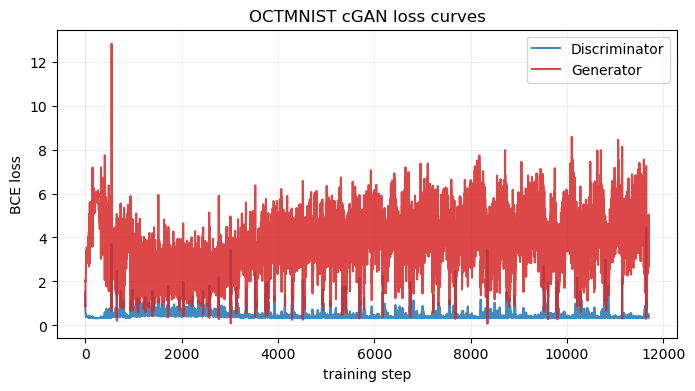

In [20]:
np.random.seed(TF_SEED); tf.random.set_seed(TF_SEED)

# oversample each class to the same size so the cGAN doesn't ignore the rare ones
per_class_count = max(1, OCT_MAX_IMAGES // octmnist_num_classes)
balanced_index = np.concatenate([
    np.random.choice(np.where(octmnist_labels == c)[0], per_class_count, replace=True)
    for c in range(octmnist_num_classes)
])
np.random.shuffle(balanced_index)
octmnist_x_balanced = preprocess_tf_images(octmnist_images[balanced_index])
octmnist_y_balanced = octmnist_labels[balanced_index].astype("int32")
conditional_dataset = (tf.data.Dataset.from_tensor_slices((octmnist_x_balanced, octmnist_y_balanced))
                       .shuffle(min(len(balanced_index), 10000))
                       .batch(OCT_BATCH, drop_remainder=True)
                       .prefetch(tf.data.AUTOTUNE))

conditional_generator = build_conditional_generator(
    octmnist_num_classes, OCT_LATENT, OCT_NGF, embedding_dim=OCT_CGAN_EMB, weight_init=OCT_INIT)
conditional_discriminator = build_conditional_discriminator(
    octmnist_num_classes, OCT_NDF, weight_init=OCT_INIT)

conditional_d_hist, conditional_g_hist = train_conditional_dcgan(
    conditional_generator, conditional_discriminator, conditional_dataset,
    OCT_CGAN_EPOCHS, octmnist_num_classes, OCT_LATENT, learning_rate=OCT_CGAN_LR, beta_1=OCT_BETA1)
tf_plot_losses(conditional_d_hist, conditional_g_hist, "OCTMNIST cGAN loss curves",
               None)

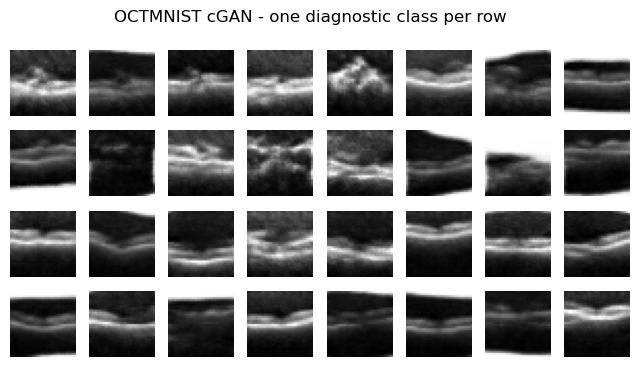

In [21]:
# one class per row to show the conditioning works
conditional_rows = []
for class_index in range(octmnist_num_classes):
    noise = tf.random.normal((8, OCT_LATENT))
    labels_row = tf.fill((8,), class_index)
    conditional_rows.append(conditional_generator([noise, labels_row], training=False).numpy())
tf_show_grid(np.concatenate(conditional_rows, axis=0),
             "OCTMNIST cGAN - one diagnostic class per row",
             None, ncols=8)

---

# Part 2.2: Cybersecurity - synthetic traffic with CICIDS 2017 (PyTorch)

This part switches back to PyTorch. The key difference from 2.1 and 2.3 is the
data type: CICIDS 2017 records are tabular network-flow statistics (durations,
inter-arrival times, packet counts, TCP flag counts and so on), not images. A
convolutional DCGAN makes no sense here because there's no spatial grid and no
neighbourhood structure to exploit, so the right model is a plain multilayer
perceptron GAN that generates a whole feature vector at once. The task is to
learn the joint distribution of these flow features well enough that synthetic
rows are statistically indistinguishable from real ones, which is genuinely
useful in security: realistic synthetic traffic can augment scarce attack data
without exposing real network captures.

## 1. Setup

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 11
torch.manual_seed(SEED); np.random.seed(SEED)

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if dev.type == "cuda":
    try:
        _ = (torch.randn(4, 4, device=dev) @ torch.randn(4, 4, device=dev)); torch.cuda.synchronize()
    except RuntimeError:
        print("CUDA kernel launch failed - falling back to CPU. Enable the GPU accelerator for this runtime.")
        dev = torch.device("cpu")

OUT_CYBER = "results_set1"
os.makedirs(OUT_CYBER, exist_ok=True)

# training budget in one place; FAST=True for a quick test run
FAST = False
EPOCHS = 3 if FAST else 60
BATCH = 256
Z_DIM_CYBER = 32
MAX_TRAIN_PER_CLASS = 2000 if FAST else 20000   # cap rows per class so training stays quick
print(f"device={dev} | epochs={EPOCHS} | out={OUT_CYBER}")

device=cuda | epochs=60 | out=results_set1


## 2. Load and explore the day-files (features and class balance)

The eight CICIDS 2017 day-files (`*.pcap_ISCX.csv`) aren't bundled with this notebook. Grab them from the [Kaggle network-intrusion dataset](https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset) and set `CICIDS_DIR` below to the folder that holds them.

In [23]:
import os, glob, contextlib, kagglehub

CICIDS_DIR = "."
day_files = [os.path.join(CICIDS_DIR, f) for f in os.listdir(CICIDS_DIR) if f.endswith(".csv")] if os.path.isdir(CICIDS_DIR) else []

if not day_files:
    print("No CSVs found locally — downloading from Kaggle...")
    with open(os.devnull, "w") as _d, contextlib.redirect_stdout(_d), contextlib.redirect_stderr(_d):
        dl_path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    day_files = glob.glob(os.path.join(dl_path, "**", "*.csv"), recursive=True)

print(f"Using {len(day_files)} CICIDS 2017 CSV files")
for p in day_files:
    print(" ", os.path.basename(p))

No CSVs found locally — downloading from Kaggle...
Using 8 CICIDS 2017 CSV files
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Wednesday-workingHours.pcap_ISCX.csv


BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
dtype: int64


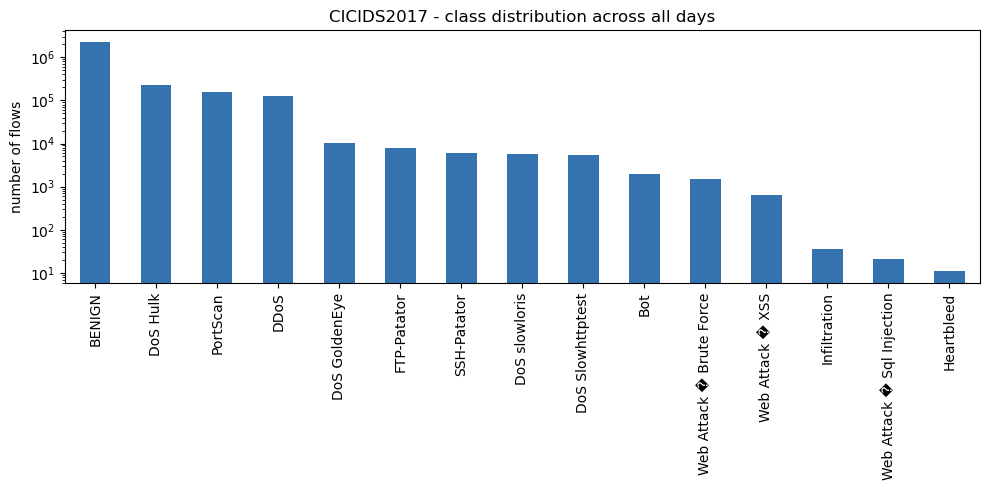

In [24]:
# read just the Label column from each file to get the overall class balance
# without loading all ~2.8M rows
def clean_columns(df):
    df.columns = [c.strip() for c in df.columns]
    return df

label_counts_all = {}
for path in day_files:
    df_labels = pd.read_csv(path, usecols=lambda c: c.strip() == "Label", low_memory=False)
    df_labels = clean_columns(df_labels)
    counts = df_labels["Label"].value_counts()
    for label, count in counts.items():
        label_counts_all[label] = label_counts_all.get(label, 0) + int(count)

label_series = pd.Series(label_counts_all).sort_values(ascending=False)
print(label_series)

plt.figure(figsize=(10, 5))
label_series.plot(kind="bar", color="#3572b0")
plt.ylabel("number of flows"); plt.title("CICIDS2017 - class distribution across all days")
plt.yscale("log")  # log scale, since BENIGN dwarfs the attack classes
plt.tight_layout()
plt.show()

## 3. Isolate and clean the Wednesday file (BENIGN + DoS)

Using: /home/ec2-user/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1/Wednesday-workingHours.pcap_ISCX.csv
Raw shape: (692703, 79)
Labels in Wednesday file: ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']
Shape after dropping inf/NaN rows: (691406, 79)
78 numeric feature columns


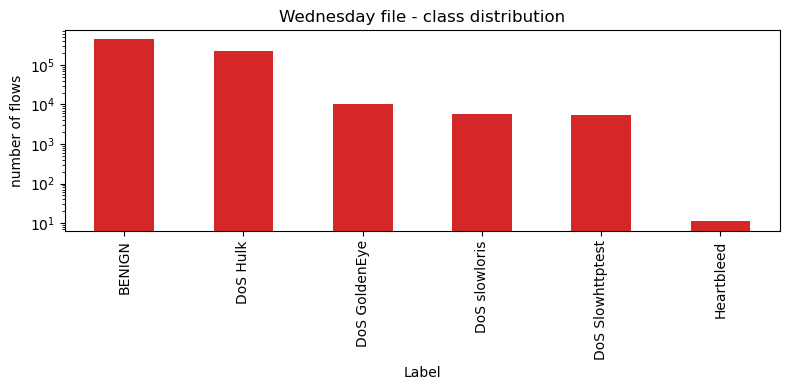

In [25]:
wednesday_path = next(p for p in day_files if "Wednesday" in os.path.basename(p))
print("Using:", wednesday_path)

df = pd.read_csv(wednesday_path, low_memory=False)
df = clean_columns(df)
print("Raw shape:", df.shape)
print("Labels in Wednesday file:", df["Label"].unique())

# CICIDS2017 has some +/-inf and NaN values (e.g. Flow Bytes/s when duration is 0);
# drop those rows rather than quietly zero-filling them
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print("Shape after dropping inf/NaN rows:", df.shape)

feature_columns = [c for c in df.columns if c != "Label"]
feature_columns = [c for c in feature_columns if pd.api.types.is_numeric_dtype(df[c])]
print(f"{len(feature_columns)} numeric feature columns")

wed_label_counts = df["Label"].value_counts()
plt.figure(figsize=(8, 4))
wed_label_counts.plot(kind="bar", color="#d62728")
plt.ylabel("number of flows"); plt.title("Wednesday file - class distribution")
plt.yscale("log")
plt.tight_layout()
plt.show()

In [26]:
# BENIGN vs attack (any DoS/Heartbleed variant), balanced subsample for training
df["is_attack"] = (df["Label"] != "BENIGN").astype(int)

benign_df = df[df["is_attack"] == 0]
attack_df = df[df["is_attack"] == 1]
print(f"BENIGN: {len(benign_df)} | DoS-attack (all variants): {len(attack_df)}")

n_per_class = min(MAX_TRAIN_PER_CLASS, len(benign_df), len(attack_df))
benign_sample = benign_df.sample(n=n_per_class, random_state=SEED)
attack_sample = attack_df.sample(n=n_per_class, random_state=SEED)
train_df = pd.concat([benign_sample, attack_sample], ignore_index=True)
train_df = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)  # shuffle
print("Training subset (balanced BENIGN/attack):", train_df.shape)

X_raw = train_df[feature_columns].values.astype(np.float32)
y_labels = train_df["Label"].values          # kept for colouring the PCA/t-SNE plots later
y_is_attack = train_df["is_attack"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)
n_features = X_scaled.shape[1]
print("Scaled feature matrix:", X_scaled.shape)

BENIGN: 439683 | DoS-attack (all variants): 251723
Training subset (balanced BENIGN/attack): (40000, 80)
Scaled feature matrix: (40000, 78)


## 4. Tabular GAN (MLP generator and discriminator, not images)

In [27]:
class TabularGenerator(nn.Module):
    """Latent noise -> a standardised feature vector. No Tanh here: the features are
    z-scored rather than bounded to [-1, 1], so a linear output fits them better."""
    def __init__(self, z_dim=Z_DIM_CYBER, hidden=256, out_dim=n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, z):
        return self.net(z)


class TabularDiscriminator(nn.Module):
    """Feature vector -> real/fake logit."""
    def __init__(self, in_dim=n_features, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)


G = TabularGenerator().to(dev)
D = TabularDiscriminator().to(dev)
print(G); print(D)

TabularGenerator(
  (net): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=256, out_features=78, bias=True)
  )
)
TabularDiscriminator(
  (net): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)


## 5. Train the tabular GAN (BENIGN + Wednesday DoS)

Same training discipline as the image parts, just adapted to vectors: Adam with
`lr=2e-4` and `betas=(0.5, 0.999)`, `BCEWithLogitsLoss` (so the discriminator
outputs a raw logit and the loss is numerically stable), and one-sided label
smoothing with a real target of 0.9. Keeping the optimiser and smoothing
identical to Parts 2.1 and 2.3 means the three GANs differ only where they
should, in architecture and data, not in training tricks.

epoch   1/60 | D 1.3548 | G 0.8257
epoch   5/60 | D 1.2664 | G 0.9509
epoch  10/60 | D 1.1970 | G 1.0421
epoch  15/60 | D 1.1780 | G 1.0443
epoch  20/60 | D 1.1257 | G 1.2358
epoch  25/60 | D 1.0924 | G 1.1491
epoch  30/60 | D 1.1515 | G 1.2894
epoch  35/60 | D 1.1004 | G 1.2297
epoch  40/60 | D 1.1028 | G 1.3772
epoch  45/60 | D 1.1141 | G 1.2802
epoch  50/60 | D 1.0672 | G 1.3687
epoch  55/60 | D 1.1094 | G 1.3801
epoch  60/60 | D 1.0248 | G 1.3455


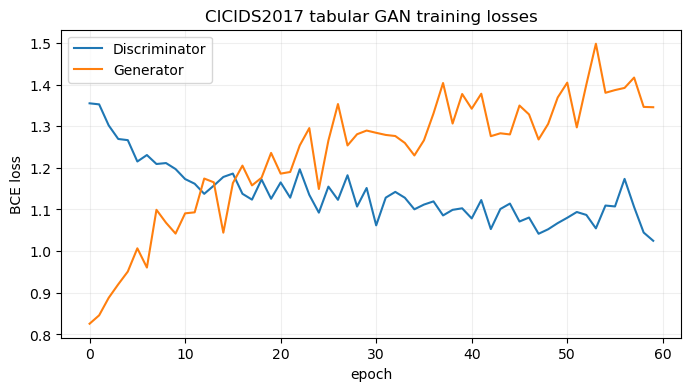

In [28]:
def train_tabular_gan(gen, disc, features_scaled, loss_title, loss_path, log_prefix=""):
    """Train a tabular GAN (BCE + one-sided label smoothing) and plot the loss curves.
    Returns (g_hist, d_hist). Reused for the Wednesday run and the full-dataset extension."""
    loader = DataLoader(TensorDataset(torch.from_numpy(features_scaled)), batch_size=BATCH,
                        shuffle=True, drop_last=True)
    opt_g = torch.optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()
    g_hist, d_hist = [], []
    for epoch in range(EPOCHS):
        for (real_batch,) in loader:
            real_batch = real_batch.to(dev)
            bs = real_batch.size(0)
            real_targets = torch.full((bs, 1), 0.9, device=dev)   # label smoothing
            fake_targets = torch.zeros((bs, 1), device=dev)
            # discriminator step
            z = torch.randn(bs, Z_DIM_CYBER, device=dev)
            fake_batch = gen(z).detach()
            d_loss = (criterion(disc(real_batch), real_targets) + criterion(disc(fake_batch), fake_targets))
            opt_d.zero_grad(); d_loss.backward(); opt_d.step()
            # generator step
            z = torch.randn(bs, Z_DIM_CYBER, device=dev)
            gen_targets = torch.ones((bs, 1), device=dev)
            g_loss = criterion(disc(gen(z)), gen_targets)
            opt_g.zero_grad(); g_loss.backward(); opt_g.step()
        g_hist.append(g_loss.item()); d_hist.append(d_loss.item())
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"{log_prefix}epoch {epoch+1:>3}/{EPOCHS} | D {d_loss.item():.4f} | G {g_loss.item():.4f}")
    plt.figure(figsize=(8, 4))
    plt.plot(d_hist, label="Discriminator"); plt.plot(g_hist, label="Generator")
    plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title(loss_title)
    plt.legend(); plt.grid(alpha=0.2)
    plt.show()
    return g_hist, d_hist

g_hist, d_hist = train_tabular_gan(G, D, X_scaled,
                                   "CICIDS2017 tabular GAN training losses", None)


## 6. Generate synthetic traffic and compare with PCA/t-SNE

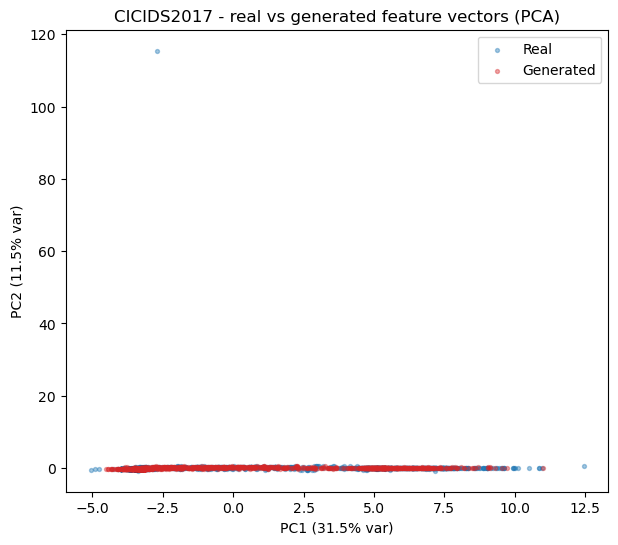

In [29]:
@torch.no_grad()
def sample_synthetic(generator, n):
    generator.eval()
    z = torch.randn(n, Z_DIM_CYBER, device=dev)
    out = generator(z).cpu().numpy()
    generator.train()
    return out

N_COMPARE = min(2000, len(X_scaled))
real_idx = np.random.choice(len(X_scaled), N_COMPARE, replace=False)
real_sample = X_scaled[real_idx]
real_sample_attack_flag = y_is_attack[real_idx]
fake_sample = sample_synthetic(G, N_COMPARE)

# fit PCA on the real data, then project both real and fake into that same space
pca = PCA(n_components=2, random_state=SEED)
real_pca = pca.fit_transform(real_sample)
fake_pca = pca.transform(fake_sample)

plt.figure(figsize=(7, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], s=8, alpha=0.4, label="Real", color="#1f77b4")
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], s=8, alpha=0.4, label="Generated", color="#d62728")
plt.title("CICIDS2017 - real vs generated feature vectors (PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend()
plt.show()

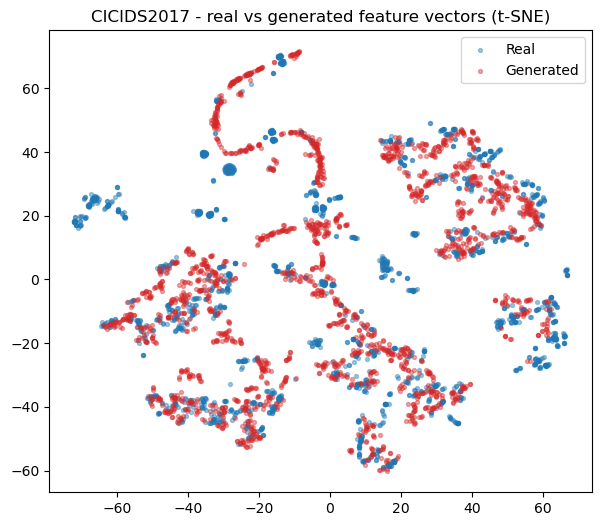

In [30]:
# t-SNE: slower, but often separates clusters that PCA blurs together
combined = np.vstack([real_sample, fake_sample])
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca")
combined_tsne = tsne.fit_transform(combined)
real_tsne, fake_tsne = combined_tsne[:N_COMPARE], combined_tsne[N_COMPARE:]

plt.figure(figsize=(7, 6))
plt.scatter(real_tsne[:, 0], real_tsne[:, 1], s=8, alpha=0.4, label="Real", color="#1f77b4")
plt.scatter(fake_tsne[:, 0], fake_tsne[:, 1], s=8, alpha=0.4, label="Generated", color="#d62728")
plt.title("CICIDS2017 - real vs generated feature vectors (t-SNE)")
plt.legend()
plt.show()

## 7. Quantitative alignment check

In [31]:
# per-feature mean/std of real vs synthetic (standardised units);
# a well-trained GAN should have small errors on most features
real_mean, real_std = real_sample.mean(axis=0), real_sample.std(axis=0)
fake_mean, fake_std = fake_sample.mean(axis=0), fake_sample.std(axis=0)

mean_abs_error = np.abs(real_mean - fake_mean)
std_abs_error = np.abs(real_std - fake_std)

alignment_df = pd.DataFrame({
    "feature": feature_columns,
    "real_mean": real_mean, "fake_mean": fake_mean, "mean_abs_error": mean_abs_error,
    "real_std": real_std, "fake_std": fake_std, "std_abs_error": std_abs_error,
}).sort_values("mean_abs_error", ascending=False)

print("Worst-aligned features (largest mean error):")
print(alignment_df.head(10).to_string(index=False))
print(f"\nOverall mean |mean error| across all {len(feature_columns)} features: {mean_abs_error.mean():.4f}")
print(f"Overall mean |std error| across all {len(feature_columns)} features:  {std_abs_error.mean():.4f}")

alignment_df.to_csv(f"{OUT_CYBER}/feature_alignment.csv", index=False)

Worst-aligned features (largest mean error):
             feature  real_mean  fake_mean  mean_abs_error  real_std  fake_std  std_abs_error
      FIN Flag Count   0.037713  -0.287888        0.325601  1.040600  0.508013       0.532587
         Bwd IAT Max   0.047185  -0.237900        0.285085  1.050526  0.600676       0.449850
      URG Flag Count   0.023164  -0.236857        0.260020  1.044548  0.029630       1.014919
         Bwd IAT Std   0.050979  -0.181376        0.232355  1.062548  0.598291       0.464257
       Bwd IAT Total   0.046574  -0.181228        0.227802  1.044443  0.787554       0.256890
    Destination Port  -0.031826  -0.243221        0.211396  0.956517  0.365944       0.590573
        Fwd IAT Mean   0.008750  -0.198604        0.207354  0.971650  0.504200       0.467450
        Bwd IAT Mean   0.021045  -0.152529        0.173574  0.942895  0.368255       0.574640
min_seg_size_forward  -0.031450   0.138532        0.169983  0.998939  0.917328       0.081611
       Fwd PSH 

## 8. Reflection

- **Alignment.** In both the PCA and t-SNE projections the generated cloud sits
  squarely on top of the main body of real points, although it is a little more
  concentrated, it captures where most traffic lives but doesn't quite reach out
  into the tails. The numbers agree with the picture. The fit on feature means
  is good (overall mean |mean error| = **0.0723** in standardised units) but
  weaker on spread (mean |std error| = **0.3179**), so the GAN reproduces average
  feature values much more faithfully than it reproduces their variance.
- **Which features struggle.** The worst-aligned features are almost all timing
  and flag columns: `FIN Flag Count`, the backward inter-arrival-time family
  (`Bwd IAT Max/Std/Total/Mean`), `Destination Port`, `Fwd IAT Mean`,
  `URG Flag Count`, `min_seg_size_forward` and `Fwd PSH Flags`. For the
  near-binary flag counts the generated standard deviation almost vanishes
  (`URG Flag Count` fake std 0.030 and `Fwd PSH Flags` fake std 0.024, against
  real values near 0.9-1.0), which means the generator effectively pins those
  features to a constant instead of reproducing their on/off behaviour. That is
  partial mode collapse on the discrete features.
- **Flaws.** This is the classic failure mode of GANs on tabular network data:
  heavy-tailed count and byte features and binary flags are the hardest to
  reproduce, and they are exactly the ones at the top of the error table.
- **"Ducks" again.** The same duck-test problem applies here, and arguably bites
  harder. A generated flow only has to satisfy the discriminator's notion of
  "looks like real traffic", which is a far weaker bar than "matches a real
  attack technique". Nothing forces the generator to respect the actual
  mechanics of a DoS attack, the timing, packet structure and flag sequences an
  attacker's tooling would really produce, so it can synthesise a flow that is
  close in aggregate (which is all the alignment gap measures) while getting the
  operationally important detail wrong. If that synthetic data were used to
  augment an IDS training set, two failure modes follow directly: a fabricated
  "attack" that matches no real signature could teach the classifier to expect
  the wrong thing and miss genuine attacks, while a fabricated "benign" flow that
  drifts toward attack-like statistics could nudge the decision boundary the
  wrong way and raise false positives. Unlike the OCT scans there is no quick
  visual sanity check for a row of 78 numbers, so the burden falls entirely on
  quantitative checks like the PCA/t-SNE overlap and the per-feature alignment
  gap, and even those, as the flag-count collapse shows, can look broadly fine
  while hiding a specific behavioural failure.
- **Label note.** The Wednesday file actually contains DoS traffic (Hulk,
  GoldenEye, slowloris, Slowhttptest, Heartbleed), not DDoS, despite the wording
  of the brief. I follow the brief literally by training on Wednesday here and
  come back to genuine DDoS (the Friday file) in the all-days extension.

## 9. Extension: the full CICIDS 2017 dataset (all days, including true DDoS)

For the extension I combine all eight day-files so the generator has to model
every attack family at once, not just Wednesday's DoS variants. To stop BENIGN
from swamping everything, I cap the number of rows per label within each file
before concatenating. This is the setting that really tests generalisation: can
a single unconditional generator cover BENIGN, several DoS types, genuine DDoS,
PortScan, brute-force and the rare web attacks all together?

In [32]:
EXT_MAX_PER_CLASS = 1000 if FAST else 8000   # smaller per-file cap, since there are many files now

def load_and_clean(path, max_rows_per_label=EXT_MAX_PER_CLASS):
    df_day = pd.read_csv(path, low_memory=False)
    df_day = clean_columns(df_day)
    df_day = df_day.replace([np.inf, -np.inf], np.nan).dropna()
    # cap rows per label so BENIGN doesn't dominate each file
    capped = [group.sample(n=min(len(group), max_rows_per_label), random_state=SEED)
              for _, group in df_day.groupby("Label")]
    return pd.concat(capped)

all_days_list = [load_and_clean(p) for p in day_files]
all_days_df = pd.concat(all_days_list, ignore_index=True)
print("Combined multi-day subset:", all_days_df.shape)
print(all_days_df["Label"].value_counts())

ext_feature_columns = [c for c in feature_columns if c in all_days_df.columns]
X_ext_raw = all_days_df[ext_feature_columns].values.astype(np.float32)
ext_labels = all_days_df["Label"].values

ext_scaler = StandardScaler()
X_ext_scaled = ext_scaler.fit_transform(X_ext_raw).astype(np.float32)
print("Extension feature matrix:", X_ext_scaled.shape)

Combined multi-day subset: (125310, 79)
Label
BENIGN                        64000
DDoS                           8000
PortScan                       8000
DoS Hulk                       8000
DoS GoldenEye                  8000
FTP-Patator                    7935
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1956
Web Attack � Brute Force       1507
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64
Extension feature matrix: (125310, 78)


[all-days] epoch   1/60 | D 1.2671 | G 0.9282
[all-days] epoch   5/60 | D 1.1387 | G 1.1248
[all-days] epoch  10/60 | D 1.1081 | G 1.2872
[all-days] epoch  15/60 | D 1.1090 | G 1.3663
[all-days] epoch  20/60 | D 1.0308 | G 1.5122
[all-days] epoch  25/60 | D 1.0323 | G 1.4427
[all-days] epoch  30/60 | D 1.0353 | G 1.5173
[all-days] epoch  35/60 | D 1.0158 | G 1.5689
[all-days] epoch  40/60 | D 1.0080 | G 1.6772
[all-days] epoch  45/60 | D 0.8958 | G 1.8159
[all-days] epoch  50/60 | D 0.9972 | G 1.6014
[all-days] epoch  55/60 | D 1.0471 | G 1.7187
[all-days] epoch  60/60 | D 1.0198 | G 1.5441


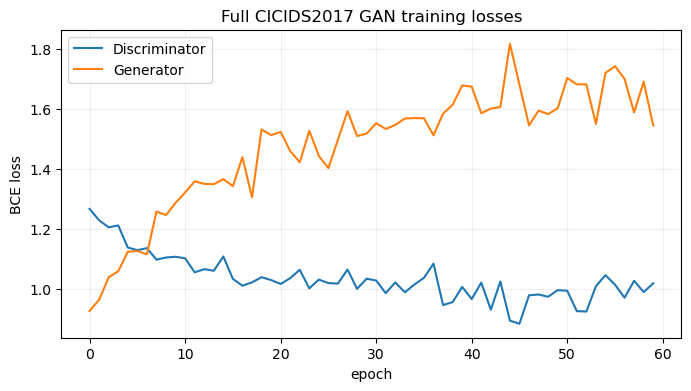

In [33]:
# reuse the same GAN classes and trainer on the wider, more varied dataset
G_ext = TabularGenerator(out_dim=X_ext_scaled.shape[1]).to(dev)
D_ext = TabularDiscriminator(in_dim=X_ext_scaled.shape[1]).to(dev)
g_hist_ext, d_hist_ext = train_tabular_gan(
    G_ext, D_ext, X_ext_scaled,
    "Full CICIDS2017 GAN training losses", None,
    log_prefix="[all-days] ")


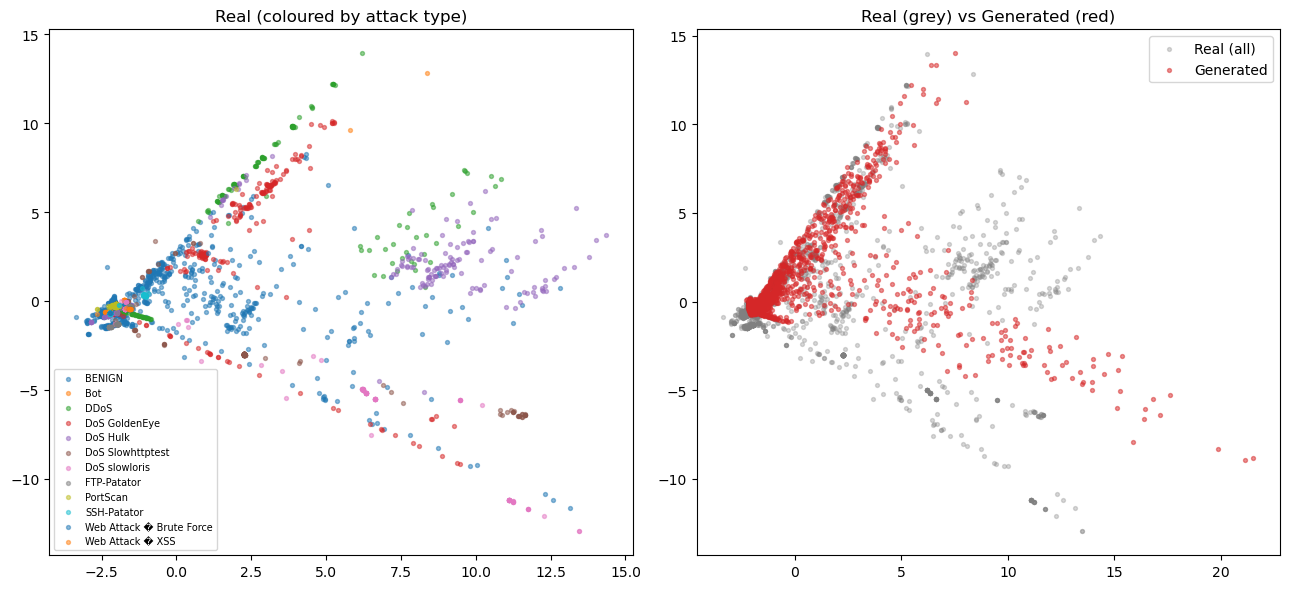

In [34]:
# PCA on the full dataset, coloured by attack type (not just attack/benign),
# to see whether the GAN covers several attack categories at once
N_EXT_COMPARE = min(3000, len(X_ext_scaled))
ext_idx = np.random.choice(len(X_ext_scaled), N_EXT_COMPARE, replace=False)
real_ext_sample = X_ext_scaled[ext_idx]
real_ext_labels_sample = ext_labels[ext_idx]
fake_ext_sample = sample_synthetic(G_ext, N_EXT_COMPARE)

pca_ext = PCA(n_components=2, random_state=SEED)
real_ext_pca = pca_ext.fit_transform(real_ext_sample)
fake_ext_pca = pca_ext.transform(fake_ext_sample)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for label in np.unique(real_ext_labels_sample):
    mask = real_ext_labels_sample == label
    axes[0].scatter(real_ext_pca[mask, 0], real_ext_pca[mask, 1], s=8, alpha=0.5, label=label)
axes[0].set_title("Real (coloured by attack type)"); axes[0].legend(fontsize=7, loc="best")
axes[1].scatter(real_ext_pca[:, 0], real_ext_pca[:, 1], s=8, alpha=0.3, label="Real (all)", color="grey")
axes[1].scatter(fake_ext_pca[:, 0], fake_ext_pca[:, 1], s=8, alpha=0.5, label="Generated", color="#d62728")
axes[1].set_title("Real (grey) vs Generated (red)"); axes[1].legend()
plt.tight_layout()
plt.show()

In [35]:
# same alignment check as section 7, now on the all-days data
real_ext_mean, real_ext_std = real_ext_sample.mean(axis=0), real_ext_sample.std(axis=0)
fake_ext_mean, fake_ext_std = fake_ext_sample.mean(axis=0), fake_ext_sample.std(axis=0)

ext_alignment = pd.DataFrame({
    "feature": ext_feature_columns,
    "real_mean": real_ext_mean, "fake_mean": fake_ext_mean,
    "mean_abs_error": np.abs(real_ext_mean - fake_ext_mean),
    "real_std": real_ext_std, "fake_std": fake_ext_std,
    "std_abs_error": np.abs(real_ext_std - fake_ext_std),
}).sort_values("mean_abs_error", ascending=False)

print("Extension - worst-aligned features (all days):")
print(ext_alignment.head(10))
print(f"\nMean |mean-gap| (all-days): {ext_alignment['mean_abs_error'].mean():.4f}")
print(f"Mean |std-gap|  (all-days): {ext_alignment['std_abs_error'].mean():.4f}")

Extension - worst-aligned features (all days):
                  feature  real_mean  fake_mean  mean_abs_error  real_std  \
47         ACK Flag Count  -0.020764  -0.449919        0.429156  0.992589   
11  Bwd Packet Length Min  -0.006239   0.350534        0.356773  1.001929   
48         URG Flag Count   0.001919  -0.325368        0.327287  1.002458   
20          Fwd IAT Total  -0.006901  -0.303967        0.297066  0.987880   
30          Fwd PSH Flags  -0.009736  -0.295473        0.285737  0.984821   
0        Destination Port   0.015010  -0.265770        0.280780  1.013894   
38      Min Packet Length  -0.011337   0.267193        0.278531  0.944231   
72             Active Max   0.027510  -0.241778        0.269288  1.038852   
44         SYN Flag Count  -0.009736  -0.275862        0.266125  0.984821   
70            Active Mean   0.038633  -0.211859        0.250491  1.084584   

    fake_std  std_abs_error  
47  0.658840       0.333750  
11  1.107961       0.106033  
48  0.107954   

## Extension reflection

Trained on every attack type at once, the generator's PCA cloud covers the dense middle of the combined data, where BENIGN and the high-volume attacks sit (`DoS Hulk`, plus the genuine `DDoS` flows from the Friday file), but it clearly under-represents the smaller outlying clusters. That's the expected outcome: a single unconditional generator has no incentive to spend capacity on classes it barely sees, and some categories stay tiny even after per-file capping (`Heartbleed` around 11 rows, `Infiltration` around 36, `Web Attack - Sql Injection` around 21).

The quantitative picture is the interesting part. Adding attack diversity actually made the alignment *worse*, not better: overall mean |mean error| rose from **0.0723** (Wednesday only) to **0.1141** (all days), and mean |std error| from **0.3179** to **0.3544**. In other words, forcing one generator to cover many modes at once cost more than the extra data gained. This time the worst-aligned features are dominated by TCP flag counts (`ACK Flag Count`, `URG Flag Count`, `SYN Flag Count`, `Fwd PSH Flags`) together with timing and activity features (`Fwd IAT Total`, `Active Max`, `Active Mean`) and a couple of packet-length statistics, whose spread the generator badly under-produces - several of the near-binary flag features collapse to almost a constant (fake std around 0.08-0.11 against a real value near 1.0). So a plain unconditional GAN does not generalise cleanly to the many-attack setting. The obvious next step is to give the rare attacks their own capacity, either with a class-conditional GAN like the one built for OCT in Part 2.1, or with a separate model per attack family.

---

# Part 2.3: Creative AI - QuickDraw 'birthday cake' DCGAN (TensorFlow/Keras)

QuickDraw's "numpy bitmap" files are 28x28 grayscale doodles, high-contrast line
art on a black background. I download the 'birthday cake' category, train a
DCGAN on it (reusing the exact builders from Part 2.1, which is a nice check that
the same architecture transfers across very different image domains), evaluate
with FID, and then extend to a couple more categories to see whether busier
sketches are harder to model. The DCGAN is again the natural fit: a doodle is
defined by where the strokes go, which is local spatial structure that
convolutions handle well.

**Dataset:** Google Creative Lab, *The Quick, Draw! Dataset*
(https://github.com/googlecreativelab/quickdraw-dataset), pulled from the public
`numpy_bitmap` mirror on Google Cloud Storage. The first run needs internet
access to download the category files.

In [36]:
# QuickDraw DCGAN config
QD_LATENT = 128
QD_NGF = 64
QD_NDF = 64
QD_LR = 0.0002
QD_BETA1 = 0.5
QD_EPOCHS = 50
QD_BATCH = 128
QD_MAX_IMAGES = 30000
QD_FID_SAMPLES = 2000
QD_INIT = "dcgan"
QD_EXTRA_CATEGORIES = ['cat', 'house']
print("QuickDraw TF config:", dict(latent=QD_LATENT, ngf=QD_NGF, ndf=QD_NDF, lr=QD_LR,
                                   epochs=QD_EPOCHS, batch=QD_BATCH, init=QD_INIT))

QuickDraw TF config: {'latent': 128, 'ngf': 64, 'ndf': 64, 'lr': 0.0002, 'epochs': 50, 'batch': 128, 'init': 'dcgan'}


## 2.3.1 Download and explore 'birthday cake'

downloading QuickDraw 'birthday cake' ...
birthday cake sketches: (144982, 28, 28)


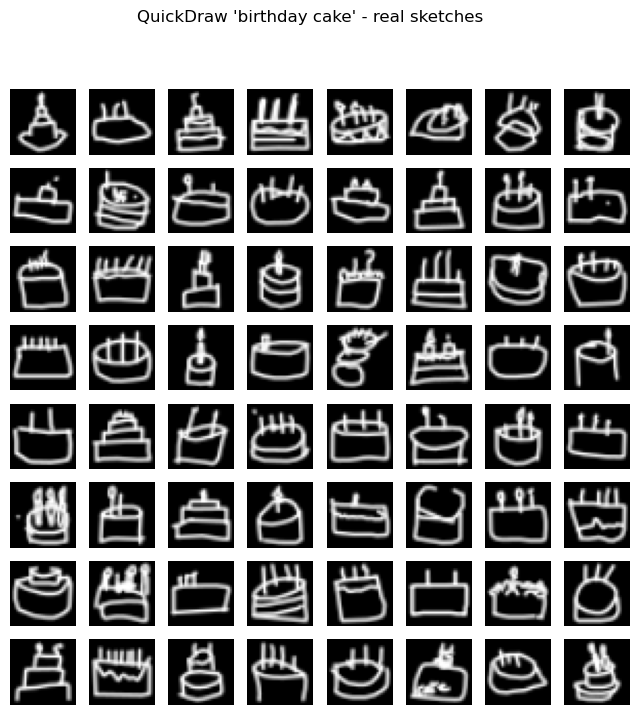

In [37]:
def download_quickdraw_bitmaps(category_name, destination_dir):
    """Download one QuickDraw 'numpy bitmap' category as (N, 28, 28) uint8. Needs internet."""
    import urllib.request
    os.makedirs(destination_dir, exist_ok=True)
    encoded = category_name.replace(" ", "%20")
    url = f"https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/{encoded}.npy"
    local_path = os.path.join(destination_dir, f"{category_name.replace(' ', '_')}.npy")
    if not os.path.exists(local_path):
        print(f"downloading QuickDraw '{category_name}' ...")
        request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request) as response, open(local_path, "wb") as handle:
            handle.write(response.read())
    return np.load(local_path).reshape(-1, 28, 28)


def sketch_ink_density(images_uint8, threshold=50):
    """Mean fraction of inked pixels, a rough proxy for sketch complexity."""
    return float((images_uint8 > threshold).mean())


quickdraw_dir = os.path.join(TF_RESULTS_DIR, "quickdraw_data")
cake_images = download_quickdraw_bitmaps("birthday cake", quickdraw_dir)
print("birthday cake sketches:", cake_images.shape)
tf_show_grid(preprocess_tf_images(cake_images[:64]), "QuickDraw 'birthday cake' - real sketches",
             None)

## 2.3.2 Build and train the DCGAN

epoch   1/50 | D=0.3622 | G=4.9971
epoch   2/50 | D=0.5111 | G=3.2589
epoch   3/50 | D=1.5353 | G=4.9964
epoch   4/50 | D=0.5709 | G=2.2815
epoch   5/50 | D=2.6166 | G=0.1613
epoch   6/50 | D=0.3865 | G=3.8954
epoch   7/50 | D=0.4863 | G=3.7103
epoch   8/50 | D=0.6022 | G=1.7539
epoch   9/50 | D=0.6757 | G=1.6002
epoch  10/50 | D=0.5963 | G=2.5163
epoch  11/50 | D=0.5097 | G=2.2099
epoch  12/50 | D=0.6428 | G=1.8631
epoch  13/50 | D=0.3570 | G=4.3664
epoch  14/50 | D=0.3770 | G=4.7539
epoch  15/50 | D=0.4845 | G=2.9151
epoch  16/50 | D=0.3567 | G=5.2212
epoch  17/50 | D=0.3562 | G=5.1371
epoch  18/50 | D=0.3446 | G=5.1060
epoch  19/50 | D=0.3990 | G=3.4899
epoch  20/50 | D=0.3589 | G=5.2508
epoch  21/50 | D=0.7641 | G=1.5257
epoch  22/50 | D=0.3430 | G=5.3899
epoch  23/50 | D=0.3834 | G=5.4569
epoch  24/50 | D=0.3468 | G=4.7368
epoch  25/50 | D=0.3648 | G=5.3420
epoch  26/50 | D=0.3623 | G=4.8488
epoch  27/50 | D=0.3389 | G=5.6706
epoch  28/50 | D=0.3419 | G=5.2297
epoch  29/50 | D=0.4

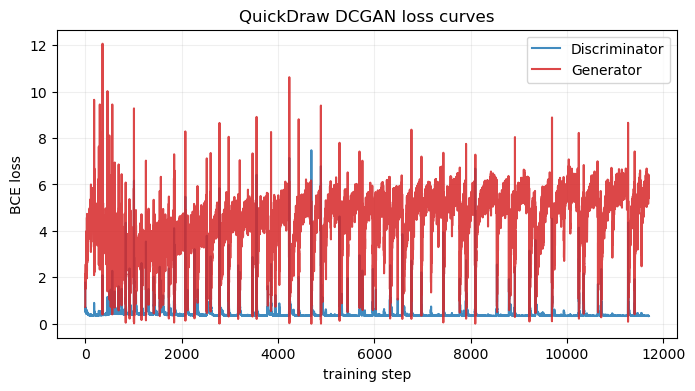

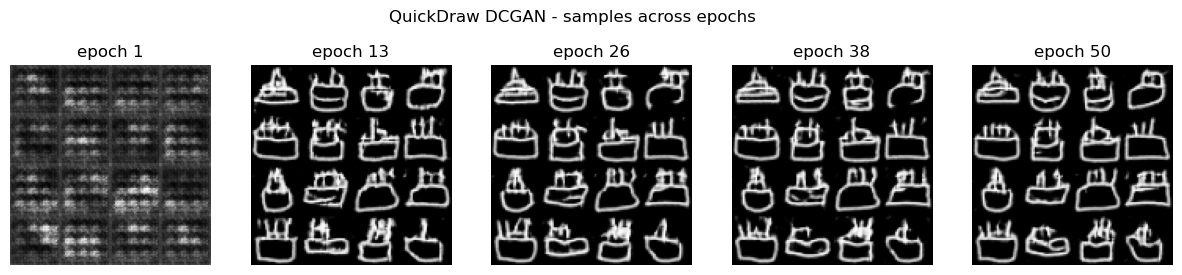

In [38]:
cake_generator, cake_d_hist, cake_g_hist, cake_snaps = train_image_dcgan(
    cake_images, QD_MAX_IMAGES, QD_LATENT, QD_NGF, QD_NDF, QD_INIT,
    QD_BATCH, QD_EPOCHS, QD_LR, QD_BETA1,
    "QuickDraw DCGAN loss curves", None,
    "QuickDraw DCGAN - samples across epochs", None)


## 2.3.3 Generate, compare against real, and compute FID

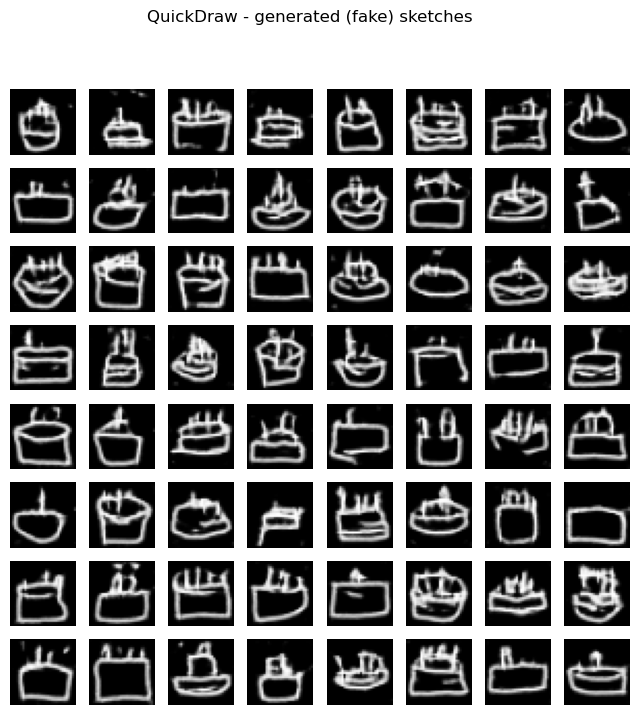

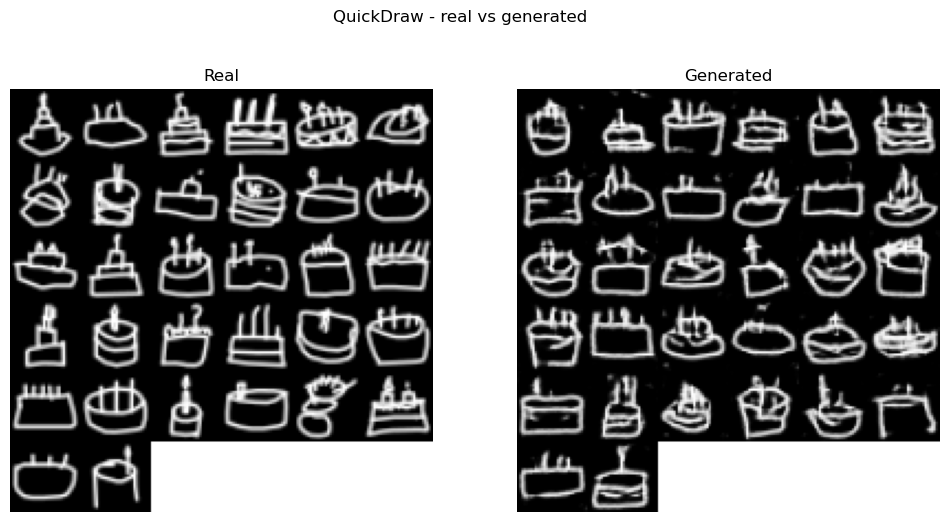

QuickDraw 'birthday cake' DCGAN FID (lower is better): 32.59


In [39]:
cake_fake, cake_fid = evaluate_image_dcgan(
    cake_generator, cake_images, QD_LATENT, QD_FID_SAMPLES, "QuickDraw 'birthday cake' DCGAN",
    "QuickDraw - generated (fake) sketches", None,
    "QuickDraw - real vs generated", None)


## 2.3 extension: other categories and sketch complexity

Here I train the identical DCGAN on two more categories and then ask a simple
question: does a busier sketch produce a worse FID? I use mean ink density (the
average fraction of inked pixels) as a rough, cheap proxy for sketch complexity
and compare it against the FID each category achieves. It's not a rigorous
complexity measure, but it's enough to see whether stroke coverage alone tracks
modelling difficulty.

downloading QuickDraw 'cat' ...
epoch   1/50 | D=0.3854 | G=4.1015
epoch   2/50 | D=0.4340 | G=3.0515
epoch   3/50 | D=0.8955 | G=1.2327
epoch   4/50 | D=0.5775 | G=1.9875
epoch   5/50 | D=0.6366 | G=1.7402
epoch   6/50 | D=0.5516 | G=3.0439
epoch   7/50 | D=1.2236 | G=2.2190
epoch   8/50 | D=0.5094 | G=2.2078
epoch   9/50 | D=0.4862 | G=2.3696
epoch  10/50 | D=0.3905 | G=3.8998
epoch  11/50 | D=0.4047 | G=3.5389
epoch  12/50 | D=0.3589 | G=4.1124
epoch  13/50 | D=0.3710 | G=3.7175
epoch  14/50 | D=0.3620 | G=4.1089
epoch  15/50 | D=0.4818 | G=2.4140
epoch  16/50 | D=1.0922 | G=4.3450
epoch  17/50 | D=0.4555 | G=4.6840
epoch  18/50 | D=0.3667 | G=4.3134
epoch  19/50 | D=0.3618 | G=4.5434
epoch  20/50 | D=0.3635 | G=3.9762
epoch  21/50 | D=0.3637 | G=4.1379
epoch  22/50 | D=0.3573 | G=4.3511
epoch  23/50 | D=0.3429 | G=5.3064
epoch  24/50 | D=0.3426 | G=5.2266
epoch  25/50 | D=0.6097 | G=3.3383
epoch  26/50 | D=0.3637 | G=4.2921
epoch  27/50 | D=0.3928 | G=3.7500
epoch  28/50 | D=0.3488

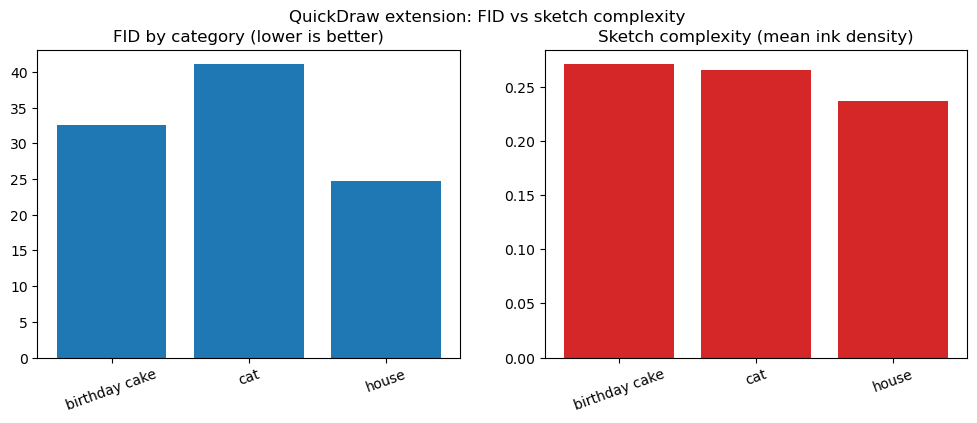

Category summary (FID | ink density):
   birthday cake: FID=32.59 | ink=0.2708
             cat: FID=41.09 | ink=0.2655
           house: FID=24.75 | ink=0.2368


In [40]:
category_fid = {"birthday cake": cake_fid}
category_ink = {"birthday cake": sketch_ink_density(cake_images)}

for extra_category in QD_EXTRA_CATEGORIES:
    np.random.seed(TF_SEED); tf.random.set_seed(TF_SEED)
    extra_images = download_quickdraw_bitmaps(extra_category, quickdraw_dir)
    category_ink[extra_category] = sketch_ink_density(extra_images)

    extra_subset = np.random.permutation(len(extra_images))[:QD_MAX_IMAGES]
    extra_dataset = (tf.data.Dataset.from_tensor_slices(preprocess_tf_images(extra_images[extra_subset]))
                     .shuffle(min(QD_MAX_IMAGES, 10000)).batch(QD_BATCH, drop_remainder=True)
                     .prefetch(tf.data.AUTOTUNE))
    extra_generator = build_dcgan_generator(QD_LATENT, QD_NGF, weight_init=QD_INIT)
    extra_discriminator = build_dcgan_discriminator(QD_NDF, weight_init=QD_INIT)
    train_dcgan(extra_generator, extra_discriminator, extra_dataset,
                QD_EPOCHS, QD_LATENT, learning_rate=QD_LR, beta_1=QD_BETA1)

    extra_fake = generate_tf_images(extra_generator, QD_FID_SAMPLES, QD_LATENT)
    extra_idx = np.random.permutation(len(extra_images))[:QD_FID_SAMPLES]
    extra_fid = frechet_inception_distance(
        to_unit_range(preprocess_tf_images(extra_images[extra_idx])), to_unit_range(extra_fake))
    category_fid[extra_category] = extra_fid
    print(f"QuickDraw '{extra_category}': FID={extra_fid:.2f} | ink density={category_ink[extra_category]:.4f}")

names = list(category_fid.keys())
figure, (fid_axis, ink_axis) = plt.subplots(1, 2, figsize=(12, 4))
fid_axis.bar(names, [category_fid[n] for n in names], color="#1f77b4")
fid_axis.set_title("FID by category (lower is better)"); fid_axis.tick_params(axis="x", rotation=20)
ink_axis.bar(names, [category_ink[n] for n in names], color="#d62728")
ink_axis.set_title("Sketch complexity (mean ink density)"); ink_axis.tick_params(axis="x", rotation=20)
figure.suptitle("QuickDraw extension: FID vs sketch complexity")
plt.show()

print("Category summary (FID | ink density):")
for name in names:
    print(f"  {name:>14}: FID={category_fid[name]:.2f} | ink={category_ink[name]:.4f}")

## 2.3.4 Reflection

- **Quality.** The generated birthday cakes are easy to read as cakes: a rounded body, candles on top, and often a plate line underneath. The grid shows plenty of variation rather than one repeated drawing, so there's no mode collapse, and the epoch snapshots (epochs 1, 13, 26, 38 and 50) show the outline and candles appearing early and then sharpening over training. The flaws are the usual line-art ones, broken or doubled strokes and a little background speckle, but the overall shape holds together.
- **Metric.** FID for birthday cake came out at **32.59** (lower is better). Interestingly that is lower than the OCT scans' **66.83**, which fits the intuition that clean, high-contrast line art on a plain black background sits more comfortably in InceptionV3's feature space than soft grayscale medical texture does.
- **Complexity vs FID (extension).** The ink-density order is house (0.2368) < cat (0.2655) < cake (0.2708), but the FID order is **house (24.75) < cake (32.59) < cat (41.09)**, so the two do *not* line up. The busiest category (cake) has the most ink yet only a middling FID, while cat has less ink than cake but the worst FID of the three, so raw ink coverage does not track modelling difficulty here. The clearest signal is that house is the easiest, with a noticeably lower FID than the other two: house sketches are largely a square plus a triangular roof, a strongly repeated template, whereas cats vary far more in pose and layout. The honest conclusion is that structural variety, more than ink coverage, drives the difficulty - and cat being the hardest despite having less ink than cake supports exactly that.
- **"Ducks" again.** The same caveat carries over: the generator will happily draw confident strokes that don't actually add up to a coherent object, so generated sketches should be eyeballed before being reused anywhere downstream.